In [1]:
# Install all libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib \
alibi captum pdpbox eli5 imbalanced-learn sdv


  Using cached torch-2.8.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (30 kB)
Using cached torch-2.8.0-cp312-cp312-manylinux_2_28_x86_64.whl (887.9 MB)


Loading the dataset

In [2]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset (update if using expanded version)
dataset_path = '/content/drive/MyDrive/Crop_recommendation.csv'

# Load dataset with basic error handling
try:
    df = pd.read_csv(dataset_path)
    print(" Dataset loaded successfully.")
    print("Shape of dataset:", df.shape)
    display(df.head())  # More readable in Colab than df.head() alone
except Exception as e:
    print(" Failed to load dataset:", e)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Dataset loaded successfully.
Shape of dataset: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


#Data inspection
Explain dataset description feature and sample output explanation


In [3]:

#  Check GPU Availability + Dataset Inspection

import torch

# GPU check (works for both CUDA and Apple MPS)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU is available: {gpu_name}")
else:
    print("⚠️ GPU not available. Running on CPU.")


#  Basic Dataset Information

print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Basic descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# Unique crops in the dataset
print("\nUnique Crops:")
print(df['label'].unique())

# Number of unique crops
print("\nNumber of unique crops:", df['label'].nunique())

# Count of samples per crop
print("\nSamples per Crop:")
print(df['label'].value_counts())


✅ GPU is available: Tesla T4

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Missing Values per Column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Descriptive Statistics:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50

#Test-train data split
Splitting dataset for 80% training and 20% testing split

In [4]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['label'])
y = df['label']

# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1760, 7)
Test size: (440, 7)


#Individual test and train accuracy of models for benchmarking
Label encoding done into numeric form as models can't read text labels
Individual ML model training and benchmarking

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Baseline Model Performance (Train vs Test) ===


,model,train_accuracy,train_f1_weighted,test_accuracy,test_f1_weighted
0,Random Forest,1.0000,1.0000,0.9955,0.9955
1,XGBoost,1.0000,1.0000,0.9932,0.9931
2,SVM (Linear),0.9926,0.9926,0.9909,0.9909
3,Logistic Regression,0.9909,0.9909,0.9841,0.9840
4,MLPClassifier,0.9818,0.9818,0.9614,0.9611


/tmp/ipython-input-2984917778.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_results_df, x='model', y='test_accuracy', palette='viridis', width=0.5)


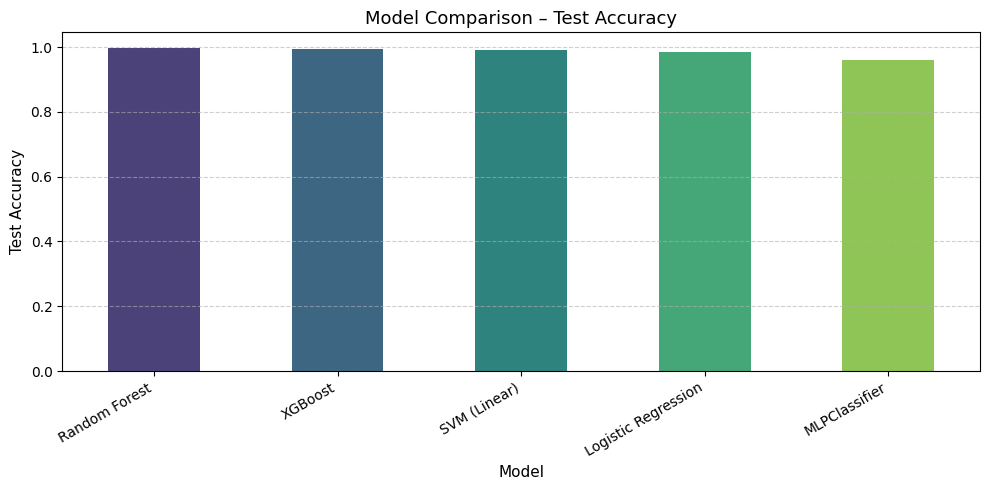

/tmp/ipython-input-2984917778.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_results_df, x='model', y='test_f1_weighted', palette='crest', width=0.5)


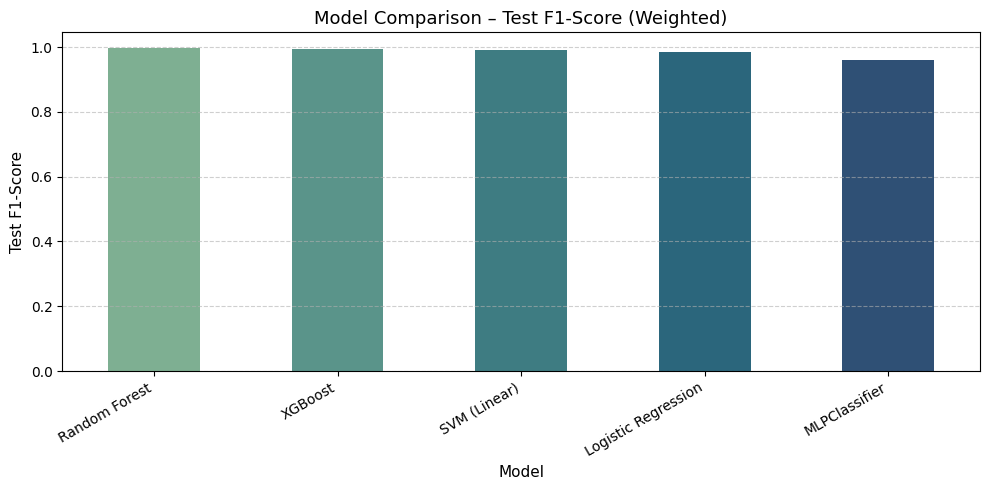

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Encode target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

#  Step 2: Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver='lbfgs'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', verbosity=0),
    "SVM (Linear)": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
}

# Step 3: Train & Evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train_encoded)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train_encoded, y_train_pred)
    train_f1 = f1_score(y_train_encoded, y_train_pred, average='weighted')
    test_acc = accuracy_score(y_test_encoded, y_test_pred)
    test_f1 = f1_score(y_test_encoded, y_test_pred, average='weighted')

    results.append({
        "model": name,
        "train_accuracy": round(train_acc, 4),
        "train_f1_weighted": round(train_f1, 4),
        "test_accuracy": round(test_acc, 4),
        "test_f1_weighted": round(test_f1, 4)
    })

#  Step 4: Display results table
baseline_results_df = pd.DataFrame(results).sort_values(by='test_f1_weighted', ascending=False).reset_index(drop=True)
print("=== Baseline Model Performance (Train vs Test) ===")
display(baseline_results_df)

# Step 5: Visualization Section
plt.figure(figsize=(10, 5))
sns.barplot(data=baseline_results_df, x='model', y='test_accuracy', palette='viridis', width=0.5)
plt.title("Model Comparison – Test Accuracy", fontsize=13)
plt.xlabel("Model", fontsize=11)
plt.ylabel("Test Accuracy", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=baseline_results_df, x='model', y='test_f1_weighted', palette='crest', width=0.5)
plt.title("Model Comparison – Test F1-Score (Weighted)", fontsize=13)
plt.xlabel("Model", fontsize=11)
plt.ylabel("Test F1-Score", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



#Case 1 - Individual feature selection -> ensemble algorithm
This also does label encoding and then further model training for generating feature importance

 Model training complete:

Logistic Regression  - Train Accuracy: 96.0227%
XGBoost              - Train Accuracy: 100.0%
RandomForest         - Train Accuracy: 100.0%
SVM (Linear)         - Train Accuracy: 99.2614%
MLPClassifier        - Train Accuracy: 98.1818%


/tmp/ipython-input-1642139332.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_acc_df, x='Model', y='Train Accuracy', palette='mako', width=0.5)


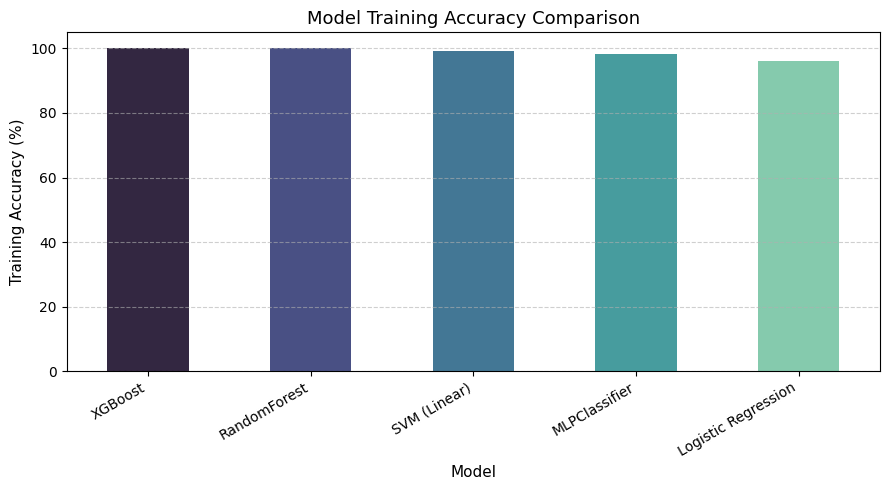

In [8]:
# Combinations to be tried:
# LogReg + SHAP
# XGBoost + SHAP
# RandomForest + SHAP
# SVM + LIME
# MLP + LIME

#  Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Label Encoding for target
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

#Dictionary to store trained models
trained_models = {}

# 1. Logistic Regression
logreg = LogisticRegression(max_iter=1000, solver='liblinear')  # removed multi_class to avoid deprecation warning
logreg.fit(X_train, y_train_encoded)
trained_models['Logistic Regression'] = logreg

# 2. XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train, y_train_encoded)
trained_models['XGBoost'] = xgb

#  3. RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train_encoded)
trained_models['RandomForest'] = rf

# 4. SVM (Linear)
svm = SVC(kernel='linear', probability=True)  # probability=True needed for LIME
svm.fit(X_train, y_train_encoded)
trained_models['SVM (Linear)'] = svm

# 5. MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train_encoded)
trained_models['MLPClassifier'] = mlp

#  Print training completion status
print(" Model training complete:\n")
training_acc_results = []
for model_name, model in trained_models.items():
    acc = model.score(X_train, y_train_encoded)
    training_acc_results.append({"Model": model_name, "Train Accuracy": round(acc * 100, 4)})
    print(f"{model_name:20s} - Train Accuracy: {round(acc * 100, 4)}%")

# Visualization: Training Accuracy Comparison
train_acc_df = pd.DataFrame(training_acc_results).sort_values(by="Train Accuracy", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=train_acc_df, x='Model', y='Train Accuracy', palette='mako', width=0.5)
plt.title("Model Training Accuracy Comparison", fontsize=13)
plt.ylabel("Training Accuracy (%)", fontsize=11)
plt.xlabel("Model", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#Model test accuracy

 Model training complete:

Logistic Regression  - Train: 96.0227% | Test: 94.3182%
XGBoost              - Train: 100.0% | Test: 99.3182%
RandomForest         - Train: 100.0% | Test: 99.5455%
SVM (Linear)         - Train: 99.2614% | Test: 99.0909%
MLPClassifier        - Train: 98.1818% | Test: 96.1364%


/tmp/ipython-input-639214110.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_df, x='Model', y='Test Accuracy', palette='mako', width=0.5)


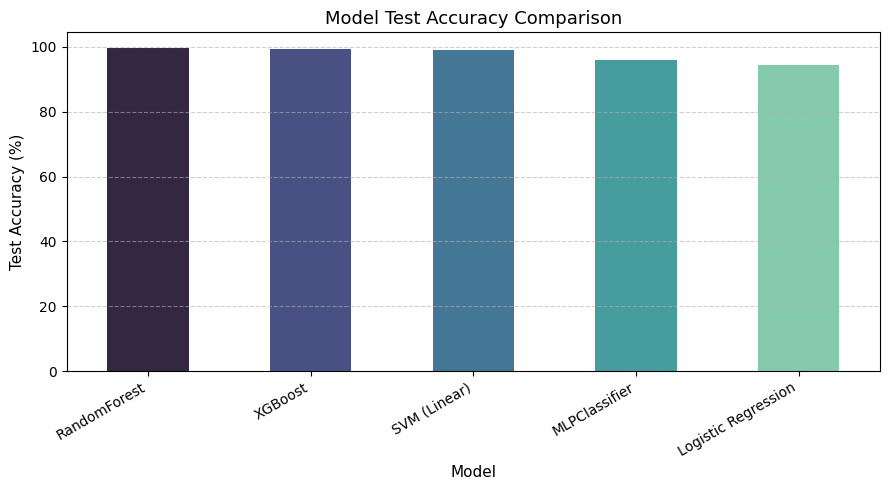

In [9]:
# Print training completion status and compute test accuracy
print(" Model training complete:\n")
performance_results = []

for model_name, model in trained_models.items():
    train_acc = model.score(X_train, y_train_encoded)
    test_acc = model.score(X_test, y_test_encoded)
    performance_results.append({
        "Model": model_name,
        "Train Accuracy": round(train_acc * 100, 4),
        "Test Accuracy": round(test_acc * 100, 4)
    })
    print(f"{model_name:20s} - Train: {round(train_acc * 100, 4)}% | Test: {round(test_acc * 100, 4)}%")

# Visualization: Test Accuracy Comparison
acc_df = pd.DataFrame(performance_results).sort_values(by="Test Accuracy", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=acc_df, x='Model', y='Test Accuracy', palette='mako', width=0.5)
plt.title("Model Test Accuracy Comparison", fontsize=13)
plt.ylabel("Test Accuracy (%)", fontsize=11)
plt.xlabel("Model", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#Generate feature imp
This uses SHAP to generate feature importance for logistic regression model to understand how each feature influences the crop prediction

In [15]:
import shap
import numpy as np
import pandas as pd

# Wrap predict_proba to fix column name warning
def predict_fn(X):
    return logreg_model.predict_proba(pd.DataFrame(X, columns=X_train.columns))

# Background sample for SHAP
X_background = shap.utils.sample(X_train, 100, random_state=42)

# Initialize KernelExplainer
explainer = shap.KernelExplainer(predict_fn, X_background)

# Compute SHAP values
shap_values = explainer.shap_values(X_train, nsamples=100)

# Confirm SHAP shape
print("len(shap_values):", len(shap_values))
print("shap_values[0].shape:", shap_values[0].shape)

# Convert to NumPy array of shape (n_samples, n_features, n_classes)
shap_array = np.array(shap_values)  # shape: (n_samples, n_features, n_classes)

# Compute mean absolute SHAP value per feature across all samples and all classes
mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))  # now shape = (7,)

# Create pandas Series for feature importance
feature_importance = pd.Series(mean_abs_shap, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

# Show final ranked features
print("✅ SHAP Feature Importance for Logistic Regression:")
display(feature_importance)


  0%|          | 0/1760 [00:00<?, ?it/s]

len(shap_values): 1760
shap_values[0].shape: (7, 22)
✅ SHAP Feature Importance for Logistic Regression:


,0
P,0.030425
K,0.030357
rainfall,0.026446
humidity,0.025398
N,0.021944
temperature,0.013142
ph,0.007196


#Plotting these shap feature for log reg

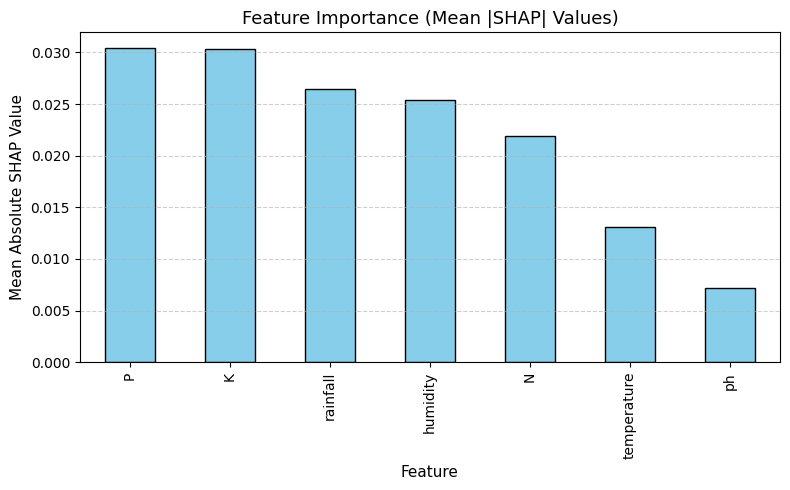

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Feature Importance (Mean |SHAP| Values)", fontsize=13)
plt.xlabel("Feature", fontsize=11)
plt.ylabel("Mean Absolute SHAP Value", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#Top k features testing on logreg model
K feature selection to see how feature contribution changes with top feature reductions

✅ Best k (by CV F1, then CV Acc): 6
Features: ['P', 'K', 'rainfall', 'humidity', 'N', 'temperature']
CV  → Acc: 0.9699 | F1w: 0.9697
Test→ Acc: 0.9750 | F1w: 0.9749


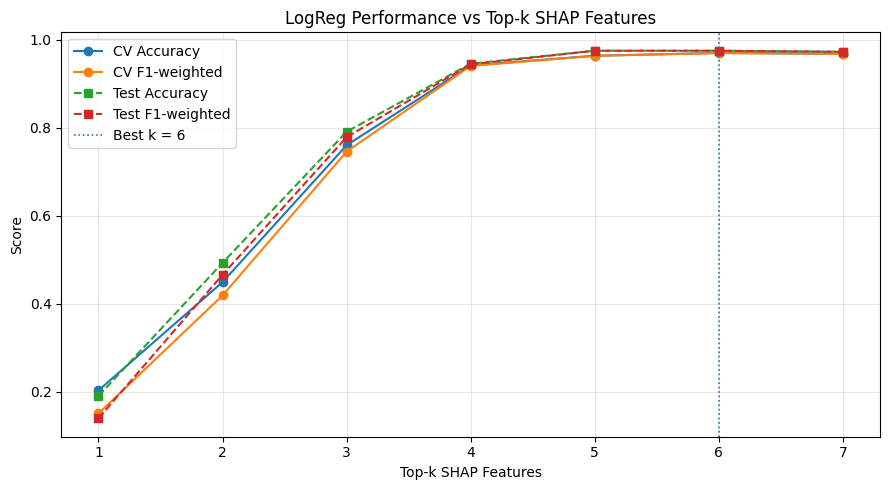

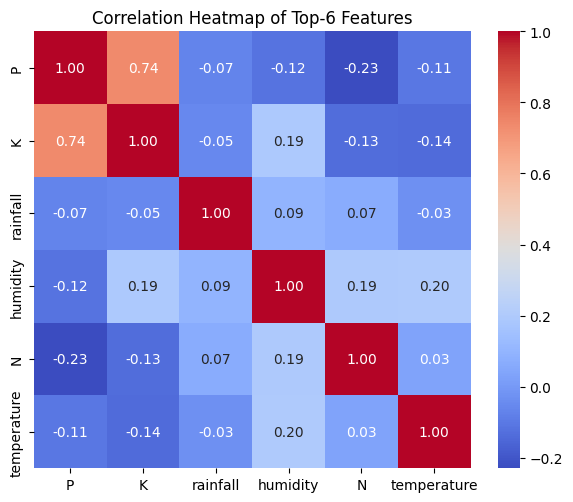

/tmp/ipython-input-4225468980.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="crest", width=0.4)


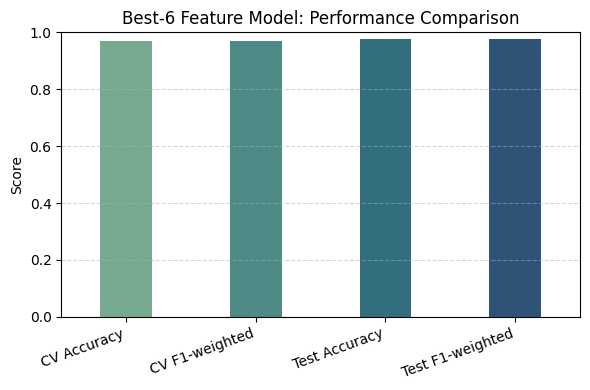

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[P],0.203409,0.151072,0.190909,0.139977
1,2,"[P, K]",0.449432,0.419137,0.493182,0.466123
2,3,"[P, K, rainfall]",0.760227,0.745770,0.790909,0.778609
3,4,"[P, K, rainfall, humidity]",0.941477,0.940552,0.945455,0.944086
4,5,"[P, K, rainfall, humidity, N]",0.963636,0.963209,0.975000,0.974896
5,6,"[P, K, rainfall, humidity, N, temperature]",0.969886,0.969667,0.975000,0.974890
6,7,"[P, K, rainfall, humidity, N, temperature, ph]",0.968182,0.967824,0.972727,0.972464


In [18]:
# LogReg + SHAP top-k loop (CV + final test)
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def make_model(class_weight=None, C=1.0, solver="lbfgs"):
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(
            max_iter=1000,
            solver=solver,
            C=C,
            class_weight=class_weight
        ))
    ])

CLASS_WEIGHT = None
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ordered_features = list(feature_importance.index)
rows = []
n_feats = len(ordered_features)

for k in range(1, n_feats + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    model = make_model(class_weight=CLASS_WEIGHT)

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    acc_cv = cross_val_score(model, Xtr_k, y_train, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model, Xtr_k, y_train, scoring="f1_weighted", cv=cv).mean()

    model.fit(Xtr_k, y_train)
    y_pred = model.predict(Xte_k)
    acc_te = accuracy_score(y_test, y_pred)
    f1w_te = f1_score(y_test, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)
best_row = results_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k = int(best_row["k_features"])
best_feats = best_row["features_used"]

print(f"✅ Best k (by CV F1, then CV Acc): {best_k}")
print("Features:", best_feats)
print(f"CV  → Acc: {best_row['cv_accuracy']:.4f} | F1w: {best_row['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_row['test_accuracy']:.4f} | F1w: {best_row['test_f1_weighted']:.4f}")

# Plot 1: Performance vs Top-k Features
plt.figure(figsize=(9,5))
plt.plot(results_df["k_features"], results_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_df["k_features"], results_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_df["k_features"], results_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_df["k_features"], results_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k, linestyle=':', linewidth=1.2, label=f"Best k = {best_k}")
plt.xlabel("Top-k SHAP Features")
plt.ylabel("Score")
plt.title("LogReg Performance vs Top-k SHAP Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#  Plot 2: Correlation Heatmap of Best-k Features
plt.figure(figsize=(6,5))
sns.heatmap(X_train[best_feats].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title(f"Correlation Heatmap of Top-{best_k} Features", fontsize=12)
plt.tight_layout()
plt.show()

# Plot 3: Bar Chart of CV vs Test Scores for Best-k
metrics = {
    "CV Accuracy": best_row["cv_accuracy"],
    "CV F1-weighted": best_row["cv_f1_weighted"],
    "Test Accuracy": best_row["test_accuracy"],
    "Test F1-weighted": best_row["test_f1_weighted"]
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="crest", width=0.4)
plt.title(f"Best-{best_k} Feature Model: Performance Comparison", fontsize=12)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


results_df.head(10)


#XGB + SHAP
Feature importance and then top k feature reduction based on shap interpret for XGB

✅ XGB SHAP feature ranking (top 10):


,0
humidity,0.963410
rainfall,0.911248
P,0.717897
N,0.523853
K,0.439101
temperature,0.234953
ph,0.128310



🏆 XGB Best k (by CV F1 → CV Acc): 7
Features: ['humidity', 'rainfall', 'P', 'N', 'K', 'temperature', 'ph']
CV  → Acc: 0.9909 | F1w: 0.9909
Test→ Acc: 0.9932 | F1w: 0.9931


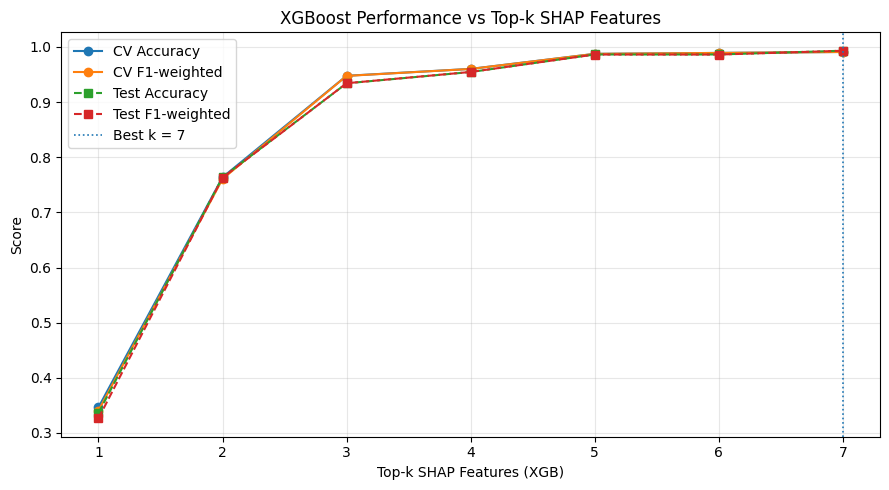

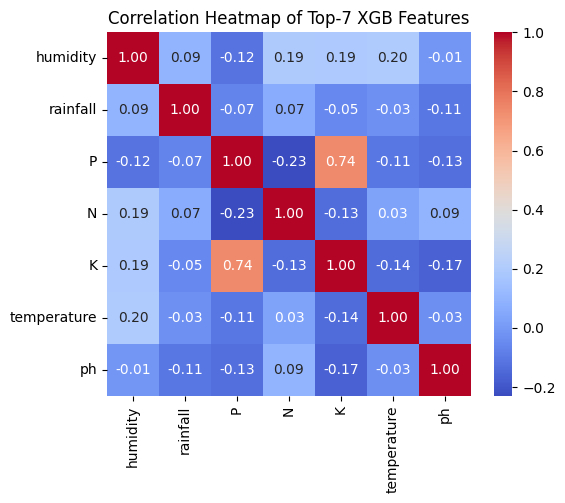

/tmp/ipython-input-513383413.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics_xgb.keys()), y=list(metrics_xgb.values()), palette="mako", width=0.4)


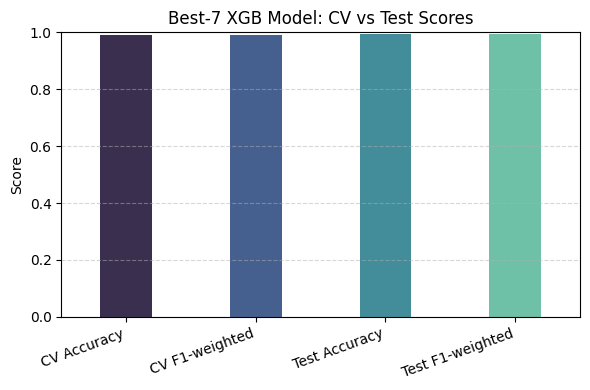

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[humidity],0.346591,0.340753,0.336364,0.326561
1,2,"[humidity, rainfall]",0.763636,0.760601,0.763636,0.762911
2,3,"[humidity, rainfall, P]",0.947727,0.947511,0.934091,0.934244
3,4,"[humidity, rainfall, P, N]",0.960227,0.960126,0.954545,0.954659
4,5,"[humidity, rainfall, P, N, K]",0.987500,0.987422,0.986364,0.986272
5,6,"[humidity, rainfall, P, N, K, temperature]",0.989205,0.989147,0.986364,0.986220
6,7,"[humidity, rainfall, P, N, K, temperature, ph]",0.990909,0.990889,0.993182,0.993116


In [20]:
# XGBoost + SHAP (TreeExplainer, model_output='raw') + top-k loop
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes: xgb (trained XGBClassifier), X_train, X_test, y_train_encoded, y_test_encoded

# 1) SHAP with TreeExplainer → use RAW margins (required with tree_path_dependent)
explainer_xgb = shap.TreeExplainer(xgb, model_output="raw")
shap_values = explainer_xgb.shap_values(X_train)

# 2) Mean |SHAP| per feature across samples & classes
def mean_abs_shap_from_any(shap_vals):
    if isinstance(shap_vals, list):
        arr = np.stack(shap_vals, axis=2)
        return np.abs(arr).mean(axis=(0, 2))
    arr = np.array(shap_vals)
    if arr.ndim == 3:
        return np.abs(arr).mean(axis=(0, 2))
    elif arr.ndim == 2:
        return np.abs(arr).mean(axis=0)
    raise ValueError(f"Unexpected SHAP shape: {arr.shape}")

mean_abs_shap_xgb = mean_abs_shap_from_any(shap_values)
feature_importance_xgb = pd.Series(mean_abs_shap_xgb, index=X_train.columns).sort_values(ascending=False)
print("✅ XGB SHAP feature ranking (top 10):")
display(feature_importance_xgb.head(10))

# 3) Top-k loop
def fresh_xgb_like(trained_xgb: XGBClassifier) -> XGBClassifier:
    return XGBClassifier(**trained_xgb.get_xgb_params())

ordered_features = list(feature_importance_xgb.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in range(1, len(ordered_features) + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    model_k = fresh_xgb_like(xgb)

    acc_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

    model_k.fit(Xtr_k, y_train_encoded)
    y_pred = model_k.predict(Xte_k)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_xgb_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)

# 4) Best k selection
best_xgb = results_xgb_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k_xgb = int(best_xgb["k_features"])
best_feats_xgb = best_xgb["features_used"]

print(f"\n🏆 XGB Best k (by CV F1 → CV Acc): {best_k_xgb}")
print("Features:", best_feats_xgb)
print(f"CV  → Acc: {best_xgb['cv_accuracy']:.4f} | F1w: {best_xgb['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_xgb['test_accuracy']:.4f} | F1w: {best_xgb['test_f1_weighted']:.4f}")

# 5) Plot 1 — Performance curves
plt.figure(figsize=(9,5))
plt.plot(results_xgb_df["k_features"], results_xgb_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_xgb_df["k_features"], results_xgb_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_xgb_df["k_features"], results_xgb_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_xgb_df["k_features"], results_xgb_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k_xgb, linestyle=':', linewidth=1.2, label=f"Best k = {best_k_xgb}")
plt.xlabel("Top-k SHAP Features (XGB)")
plt.ylabel("Score")
plt.title("XGBoost Performance vs Top-k SHAP Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 — Correlation Heatmap of Best-k Features
plt.figure(figsize=(6,5))
sns.heatmap(X_train[best_feats_xgb].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title(f"Correlation Heatmap of Top-{best_k_xgb} XGB Features", fontsize=12)
plt.tight_layout()
plt.show()

# Plot 3 — Bar Chart: CV vs Test Scores for Best-k Model
metrics_xgb = {
    "CV Accuracy": best_xgb["cv_accuracy"],
    "CV F1-weighted": best_xgb["cv_f1_weighted"],
    "Test Accuracy": best_xgb["test_accuracy"],
    "Test F1-weighted": best_xgb["test_f1_weighted"]
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(metrics_xgb.keys()), y=list(metrics_xgb.values()), palette="mako", width=0.4)
plt.title(f"Best-{best_k_xgb} XGB Model: CV vs Test Scores", fontsize=12)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

results_xgb_df.head(10)


#Random forest + SHAP
Feature importance and then top k feature reduction based on shap interpret for XGB

✅ RF SHAP feature ranking (top 10):


,0
humidity,0.032354
K,0.027706
rainfall,0.025991
N,0.025946
P,0.024081
temperature,0.010551
ph,0.005100



🏆 RF Best k (by CV F1 → CV Acc): 6
Features: ['humidity', 'K', 'rainfall', 'N', 'P', 'temperature']
CV  → Acc: 0.9943 | F1w: 0.9943
Test→ Acc: 0.9886 | F1w: 0.9886


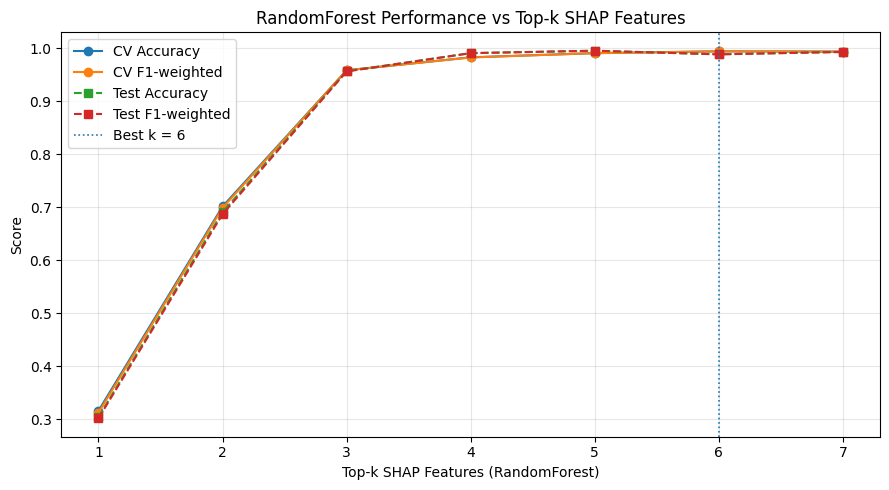

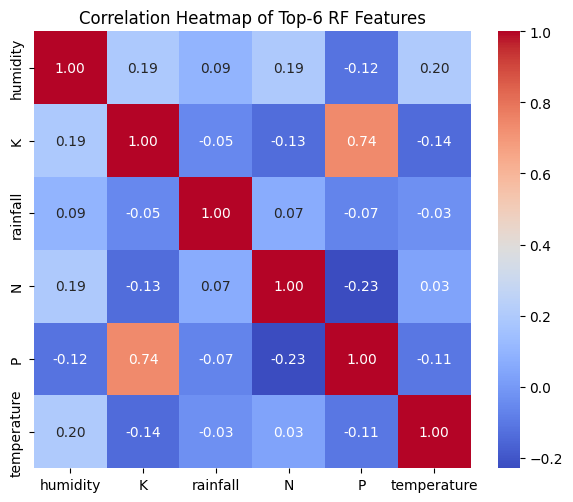

/tmp/ipython-input-1812793048.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics_rf.keys()), y=list(metrics_rf.values()), palette="flare", width=0.4)


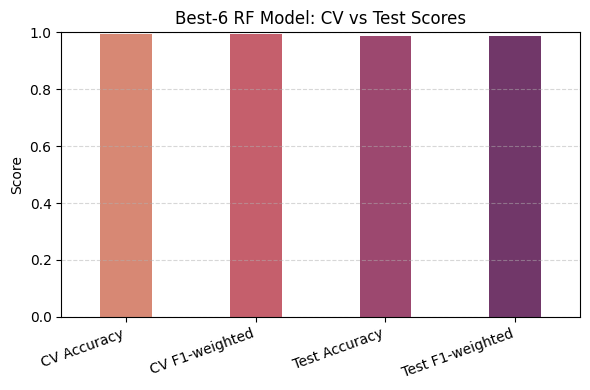

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[humidity],0.316477,0.312820,0.304545,0.302060
1,2,"[humidity, K]",0.701705,0.699054,0.690909,0.687026
2,3,"[humidity, K, rainfall]",0.958523,0.958506,0.956818,0.956320
3,4,"[humidity, K, rainfall, N]",0.982955,0.982748,0.990909,0.990843
4,5,"[humidity, K, rainfall, N, P]",0.990909,0.990764,0.995455,0.995452
5,6,"[humidity, K, rainfall, N, P, temperature]",0.994318,0.994277,0.988636,0.988612
6,7,"[humidity, K, rainfall, N, P, temperature, ph]",0.993750,0.993730,0.993182,0.993178


In [21]:
# RandomForest + SHAP (TreeExplainer, model_output='raw') + top-k loop
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes rf (trained RandomForestClassifier) exists
# rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train_encoded)

#  1) SHAP with TreeExplainer
explainer_rf = shap.TreeExplainer(rf, model_output="raw")
shap_values_rf = explainer_rf.shap_values(X_train)

def mean_abs_shap_from_any(shap_vals):
    if isinstance(shap_vals, list):
        arr = np.stack(shap_vals, axis=2)
        return np.abs(arr).mean(axis=(0, 2))
    arr = np.array(shap_vals)
    if arr.ndim == 3:
        return np.abs(arr).mean(axis=(0, 2))
    elif arr.ndim == 2:
        return np.abs(arr).mean(axis=0)
    raise ValueError(f"Unexpected SHAP shape: {arr.shape}")

mean_abs_shap_rf = mean_abs_shap_from_any(shap_values_rf)

# 2) Feature ranking
feature_importance_rf = pd.Series(mean_abs_shap_rf, index=X_train.columns).sort_values(ascending=False)
print("✅ RF SHAP feature ranking (top 10):")
display(feature_importance_rf.head(10))

#  3) Top-k loop
ordered_features = list(feature_importance_rf.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in range(1, len(ordered_features) + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    model_k = clone(rf)

    acc_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

    model_k.fit(Xtr_k, y_train_encoded)
    y_pred = model_k.predict(Xte_k)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_rf_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)

#  4) Best k selection
best_rf = results_rf_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k_rf = int(best_rf["k_features"])
best_feats_rf = best_rf["features_used"]

print(f"\n🏆 RF Best k (by CV F1 → CV Acc): {best_k_rf}")
print("Features:", best_feats_rf)
print(f"CV  → Acc: {best_rf['cv_accuracy']:.4f} | F1w: {best_rf['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_rf['test_accuracy']:.4f} | F1w: {best_rf['test_f1_weighted']:.4f}")

#  5) Plot 1 — Performance curves
plt.figure(figsize=(9,5))
plt.plot(results_rf_df["k_features"], results_rf_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_rf_df["k_features"], results_rf_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_rf_df["k_features"], results_rf_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_rf_df["k_features"], results_rf_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k_rf, linestyle=':', linewidth=1.2, label=f"Best k = {best_k_rf}")
plt.xlabel("Top-k SHAP Features (RandomForest)")
plt.ylabel("Score")
plt.title("RandomForest Performance vs Top-k SHAP Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 — Correlation Heatmap of Best-k Features
plt.figure(figsize=(6,5))
sns.heatmap(X_train[best_feats_rf].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title(f"Correlation Heatmap of Top-{best_k_rf} RF Features", fontsize=12)
plt.tight_layout()
plt.show()

#  Plot 3 — Bar Chart: CV vs Test Scores for Best-k
metrics_rf = {
    "CV Accuracy": best_rf["cv_accuracy"],
    "CV F1-weighted": best_rf["cv_f1_weighted"],
    "Test Accuracy": best_rf["test_accuracy"],
    "Test F1-weighted": best_rf["test_f1_weighted"]
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(metrics_rf.keys()), y=list(metrics_rf.values()), palette="flare", width=0.4)
plt.title(f"Best-{best_k_rf} RF Model: CV vs Test Scores", fontsize=12)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: view table
results_rf_df.head(10)


#SVM + LIME
Feature importance and then top k feature reduction based on lime interpret for SVM

✅ SVM+LIME global feature importance (top 10):


,0
P,0.071833
N,0.062005
ph,0.029111
humidity,0.025712
rainfall,0.020035
temperature,0.014009
K,0.013685



🏆 SVM+LIME Best k: 7
Features: ['P', 'N', 'ph', 'humidity', 'rainfall', 'temperature', 'K']
CV  → Acc: 0.9818 | F1w: 0.9815
Test→ Acc: 0.9818 | F1w: 0.9817


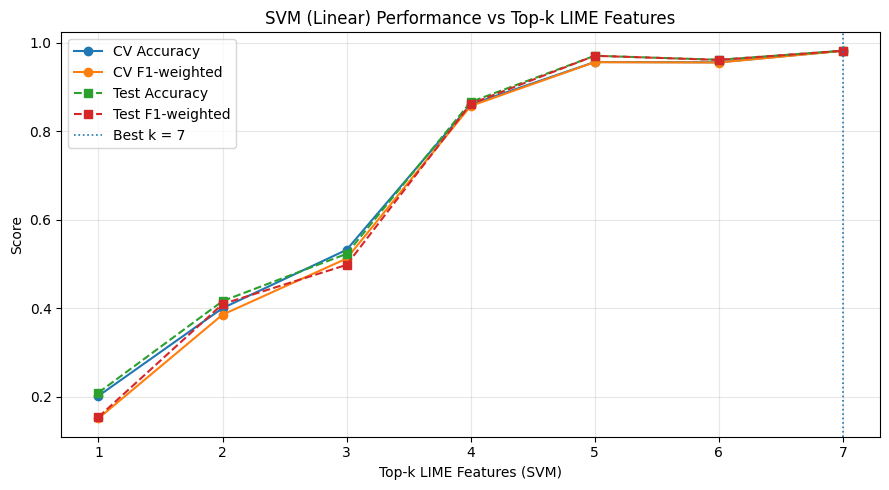

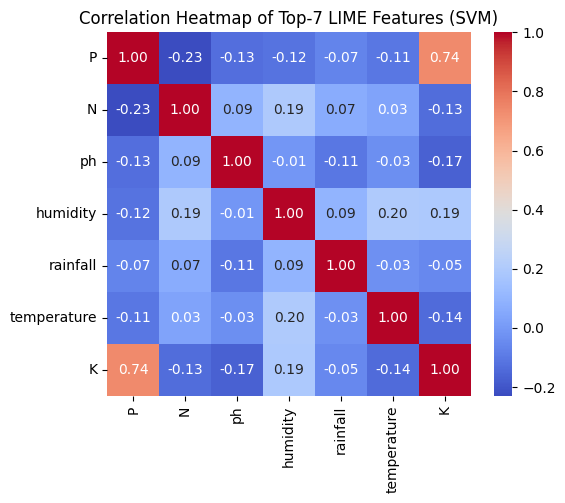

/tmp/ipython-input-2568429702.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics_svm.keys()), y=list(metrics_svm.values()), palette="crest", width=0.4)


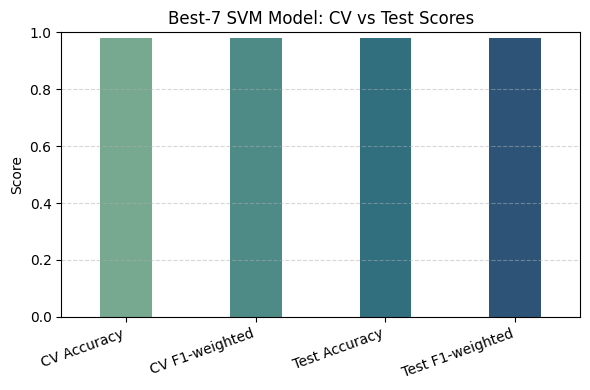

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[P],0.201705,0.150936,0.209091,0.154008
1,2,"[P, N]",0.400000,0.385236,0.415909,0.409214
2,3,"[P, N, ph]",0.531818,0.512062,0.522727,0.497761
3,4,"[P, N, ph, humidity]",0.860227,0.856892,0.865909,0.861623
4,5,"[P, N, ph, humidity, rainfall]",0.956250,0.955871,0.970455,0.970350
5,6,"[P, N, ph, humidity, rainfall, temperature]",0.955682,0.955092,0.961364,0.961026
6,7,"[P, N, ph, humidity, rainfall, temperature, K]",0.981818,0.981505,0.981818,0.981715


In [22]:
# SVM + LIME (global importance via averaged local weights) + top-k loop
!pip install -q lime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from lime.lime_tabular import LimeTabularExplainer

# 1) Build SVM pipeline
def make_svm(C=1.0, class_weight=None):
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", SVC(kernel="linear", C=C, probability=True, class_weight=class_weight))
    ])

svm_pipe = make_svm(C=1.0, class_weight=None)
svm_pipe.fit(X_train, y_train_encoded)

# 2) LIME explainer setup
feature_names = list(X_train.columns)
class_names = [str(c) for c in label_encoder.classes_]
explainer = LimeTabularExplainer(
    training_data=X_train.values.astype(float),
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode="classification",
    sample_around_instance=True,
    random_state=42
)

# 3) Global LIME importance
def global_lime_importance(model, X, m_instances=200, num_features=None):
    num_features = num_features or X.shape[1]
    m = min(m_instances, len(X))
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X), size=m, replace=False)
    agg = np.zeros(X.shape[1], dtype=float)
    counts = np.zeros(X.shape[1], dtype=float)

    for i in idx:
        exp = explainer.explain_instance(
            data_row=X.iloc[i].values.astype(float),
            predict_fn=lambda z: model.predict_proba(pd.DataFrame(z, columns=X.columns)),
            num_features=num_features
        )
        for label, feats in exp.as_map().items():
            for j, w in feats:
                agg[j] += abs(w)
                counts[j] += 1.0

    counts[counts == 0] = 1.0
    mean_abs = agg / counts
    return pd.Series(mean_abs, index=X.columns).sort_values(ascending=False)

feature_importance_lime = global_lime_importance(svm_pipe, X_train, m_instances=200)
print("✅ SVM+LIME global feature importance (top 10):")
display(feature_importance_lime.head(10))

# 4) Top-k loop
ordered_features = list(feature_importance_lime.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in range(1, len(ordered_features) + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    model_k = make_svm(C=1.0, class_weight=None)

    acc_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

    model_k.fit(Xtr_k, y_train_encoded)
    y_pred = model_k.predict(Xte_k)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_svm_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)

# 5) Select best k
best_svm = results_svm_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k_svm = int(best_svm["k_features"])
best_feats_svm = best_svm["features_used"]

print(f"\n🏆 SVM+LIME Best k: {best_k_svm}")
print("Features:", best_feats_svm)
print(f"CV  → Acc: {best_svm['cv_accuracy']:.4f} | F1w: {best_svm['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_svm['test_accuracy']:.4f} | F1w: {best_svm['test_f1_weighted']:.4f}")

# 6) Plot 1 — Performance curves
plt.figure(figsize=(9,5))
plt.plot(results_svm_df["k_features"], results_svm_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_svm_df["k_features"], results_svm_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_svm_df["k_features"], results_svm_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_svm_df["k_features"], results_svm_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k_svm, linestyle=':', linewidth=1.2, label=f"Best k = {best_k_svm}")
plt.xlabel("Top-k LIME Features (SVM)")
plt.ylabel("Score")
plt.title("SVM (Linear) Performance vs Top-k LIME Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 7) Plot 2 — Correlation Heatmap of Best-k Features
plt.figure(figsize=(6,5))
sns.heatmap(X_train[best_feats_svm].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title(f"Correlation Heatmap of Top-{best_k_svm} LIME Features (SVM)", fontsize=12)
plt.tight_layout()
plt.show()

# 8) Plot 3 — Bar Chart: CV vs Test Scores for Best-k Model
metrics_svm = {
    "CV Accuracy": best_svm["cv_accuracy"],
    "CV F1-weighted": best_svm["cv_f1_weighted"],
    "Test Accuracy": best_svm["test_accuracy"],
    "Test F1-weighted": best_svm["test_f1_weighted"]
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(metrics_svm.keys()), y=list(metrics_svm.values()), palette="crest", width=0.4)
plt.title(f"Best-{best_k_svm} SVM Model: CV vs Test Scores", fontsize=12)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: preview results table
results_svm_df.head(10)


#MLP + lime
Feature importance and then top k feature reduction based on lime interpret for MLP

✅ MLP+LIME global feature importance (top 10):


,0
P,0.074293
N,0.073019
humidity,0.032210
ph,0.031870
rainfall,0.024047
temperature,0.019705
K,0.010302



🏆 MLP+LIME Best k: 7
Features: ['P', 'N', 'humidity', 'ph', 'rainfall', 'temperature', 'K']
CV  → Acc: 0.9710 | F1w: 0.9709
Test→ Acc: 0.9795 | F1w: 0.9794


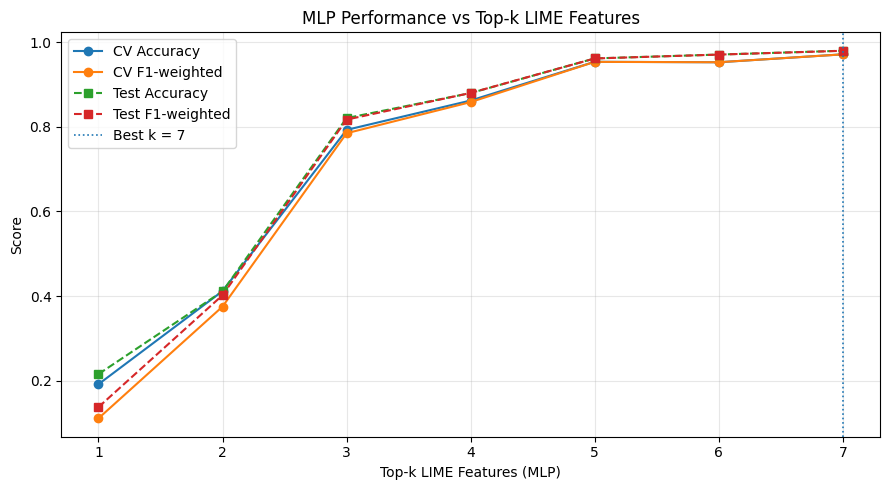

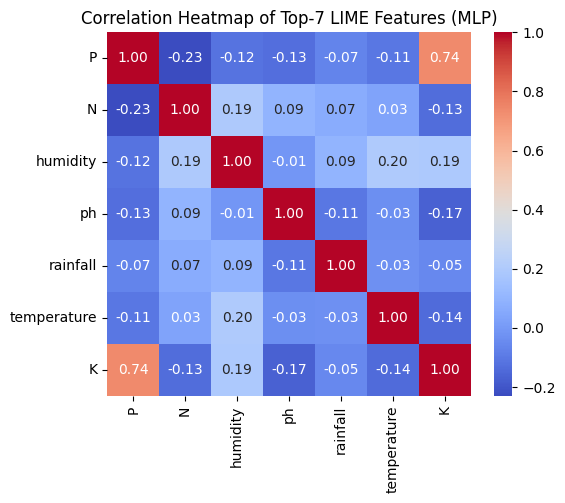

/tmp/ipython-input-3657225703.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics_mlp.keys()), y=list(metrics_mlp.values()), palette="mako", width=0.4)


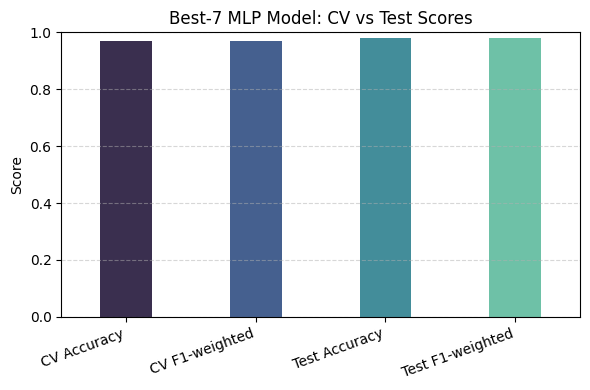

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[P],0.192045,0.111443,0.215909,0.137962
1,2,"[P, N]",0.411932,0.375372,0.411364,0.402222
2,3,"[P, N, humidity]",0.792614,0.784661,0.820455,0.816860
3,4,"[P, N, humidity, ph]",0.861932,0.858220,0.879545,0.879806
4,5,"[P, N, humidity, ph, rainfall]",0.953409,0.953188,0.961364,0.961211
5,6,"[P, N, humidity, ph, rainfall, temperature]",0.952273,0.952327,0.970455,0.970370
6,7,"[P, N, humidity, ph, rainfall, temperature, K]",0.971023,0.970899,0.979545,0.979393


In [23]:
#  MLP + LIME (global importance via averaged local weights) + top-k loop
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from lime.lime_tabular import LimeTabularExplainer

# 1) Build MLP pipeline
def make_mlp(hidden=(100,), alpha=1e-4, lr_init=1e-3, early_stop=True, random_state=42):
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=hidden,
            activation="relu",
            solver="adam",
            alpha=alpha,
            learning_rate_init=lr_init,
            max_iter=1000,
            early_stopping=early_stop,
            n_iter_no_change=20,
            validation_fraction=0.1,
            random_state=random_state,
            verbose=False
        ))
    ])

mlp_pipe = make_mlp(hidden=(128, 64), alpha=1e-4, lr_init=1e-3, early_stop=True)
mlp_pipe.fit(X_train, y_train_encoded)

# 2) LIME explainer setup
feature_names = list(X_train.columns)
class_names = [str(c) for c in label_encoder.classes_]
explainer = LimeTabularExplainer(
    training_data=X_train.values.astype(float),
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode="classification",
    sample_around_instance=True,
    random_state=42
)

# 3) Global LIME importance
def global_lime_importance(model, X, m_instances=200, num_features=None):
    num_features = num_features or X.shape[1]
    m = min(m_instances, len(X))
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X), size=m, replace=False)

    agg = np.zeros(X.shape[1], dtype=float)
    counts = np.zeros(X.shape[1], dtype=float)

    for i in idx:
        exp = explainer.explain_instance(
            data_row=X.iloc[i].values.astype(float),
            predict_fn=lambda z: model.predict_proba(pd.DataFrame(z, columns=X.columns)),
            num_features=num_features
        )
        amap = exp.as_map()
        for _, feats in amap.items():
            for j, w in feats:
                agg[j] += abs(w)
                counts[j] += 1.0

    counts[counts == 0] = 1.0
    mean_abs = agg / counts
    return pd.Series(mean_abs, index=X.columns).sort_values(ascending=False)

feature_importance_lime_mlp = global_lime_importance(mlp_pipe, X_train, m_instances=200)
print("✅ MLP+LIME global feature importance (top 10):")
display(feature_importance_lime_mlp.head(10))

# 4) Top-k loop
ordered_features = list(feature_importance_lime_mlp.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in range(1, len(ordered_features) + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    model_k = make_mlp(hidden=(128, 64), alpha=1e-4, lr_init=1e-3, early_stop=True)

    acc_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

    model_k.fit(Xtr_k, y_train_encoded)
    y_pred = model_k.predict(Xte_k)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_mlp_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)

# 5) Select best k
best_mlp = results_mlp_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k_mlp = int(best_mlp["k_features"])
best_feats_mlp = best_mlp["features_used"]

print(f"\n🏆 MLP+LIME Best k: {best_k_mlp}")
print("Features:", best_feats_mlp)
print(f"CV  → Acc: {best_mlp['cv_accuracy']:.4f} | F1w: {best_mlp['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_mlp['test_accuracy']:.4f} | F1w: {best_mlp['test_f1_weighted']:.4f}")

# 6) Plot 1 — Performance curves
plt.figure(figsize=(9,5))
plt.plot(results_mlp_df["k_features"], results_mlp_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_mlp_df["k_features"], results_mlp_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_mlp_df["k_features"], results_mlp_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_mlp_df["k_features"], results_mlp_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k_mlp, linestyle=':', linewidth=1.2, label=f"Best k = {best_k_mlp}")
plt.xlabel("Top-k LIME Features (MLP)")
plt.ylabel("Score")
plt.title("MLP Performance vs Top-k LIME Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 7) Plot 2 — Correlation Heatmap of Best-k Features
plt.figure(figsize=(6,5))
sns.heatmap(X_train[best_feats_mlp].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title(f"Correlation Heatmap of Top-{best_k_mlp} LIME Features (MLP)", fontsize=12)
plt.tight_layout()
plt.show()

# 8) Plot 3 — Bar Chart: CV vs Test Scores for Best-k Model
metrics_mlp = {
    "CV Accuracy": best_mlp["cv_accuracy"],
    "CV F1-weighted": best_mlp["cv_f1_weighted"],
    "Test Accuracy": best_mlp["test_accuracy"],
    "Test F1-weighted": best_mlp["test_f1_weighted"]
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(metrics_mlp.keys()), y=list(metrics_mlp.values()), palette="mako", width=0.4)
plt.title(f"Best-{best_k_mlp} MLP Model: CV vs Test Scores", fontsize=12)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: peek at table
results_mlp_df.head(10)


#Case 1 compile results
It combines the best k feature individual model + explainable models and finds the top performing combination which comes out to be XGB + shap

✅ Best Model + XAI combos (by hold-out Test F1 → Test Acc):


,model,best_k,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,XGBoost + SHAP,7,"humidity, rainfall, P, N, K, temperature, ph",0.990909,0.990889,0.993182,0.993116
1,RandomForest + SHAP,6,"humidity, K, rainfall, N, P, temperature",0.994318,0.994277,0.988636,0.988612
2,SVM (Linear) + LIME,7,"P, N, ph, humidity, rainfall, temperature, K",0.981818,0.981505,0.981818,0.981715
3,MLP + LIME,7,"P, N, humidity, ph, rainfall, temperature, K",0.971023,0.970899,0.979545,0.979393
4,LogReg + SHAP,6,"P, K, rainfall, humidity, N, temperature",0.969886,0.969667,0.975000,0.974890



— Brief Comparison —
1. XGBoost + SHAP       | k= 7 | CV Acc=0.9909  CV F1=0.9909  | Test Acc=0.9932  Test F1=0.9931
2. RandomForest + SHAP  | k= 6 | CV Acc=0.9943  CV F1=0.9943  | Test Acc=0.9886  Test F1=0.9886
3. SVM (Linear) + LIME  | k= 7 | CV Acc=0.9818  CV F1=0.9815  | Test Acc=0.9818  Test F1=0.9817
4. MLP + LIME           | k= 7 | CV Acc=0.9710  CV F1=0.9709  | Test Acc=0.9795  Test F1=0.9794
5. LogReg + SHAP        | k= 6 | CV Acc=0.9699  CV F1=0.9697  | Test Acc=0.9750  Test F1=0.9749

🏆 Champion: XGBoost + SHAP | k=7 | Test Acc=0.9932, Test F1=0.9931
Features used: humidity, rainfall, P, N, K, temperature, ph


/tmp/ipython-input-5218066.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="model", y="test_accuracy", palette="crest", width=0.5, label="Test Accuracy")
/tmp/ipython-input-5218066.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="model", y="test_f1_weighted", palette="flare", width=0.3, label="Test F1", alpha=0.7)


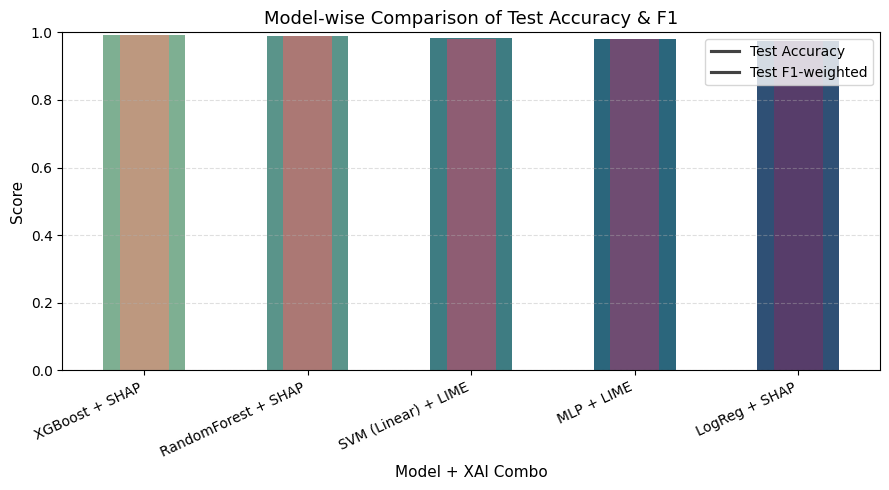

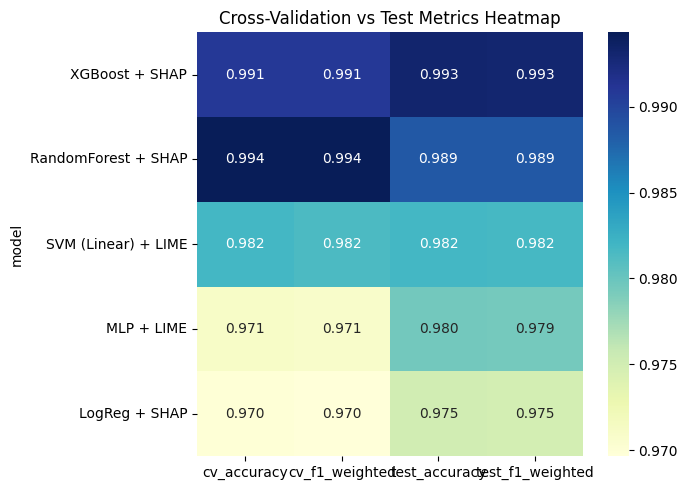

/tmp/ipython-input-5218066.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="model", y="best_k", palette="viridis", width=0.4)


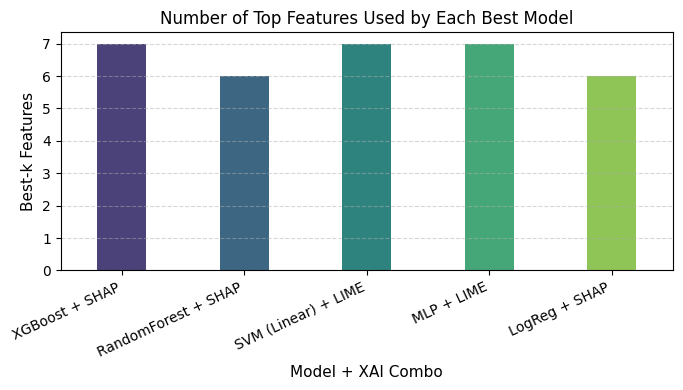

In [24]:
#  Compile & compare Model + XAI results (best-k per model)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def pick_best_row(df: pd.DataFrame):
    """Select best row by CV F1 → CV Acc → smaller k."""
    return (df.sort_values(
        by=["cv_f1_weighted", "cv_accuracy", "k_features"],
        ascending=[False, False, True]
    ).iloc[0])

# Map: friendly name -> results dataframe variable name
cand_dfs = {
    "LogReg + SHAP":      "results_df",
    "XGBoost + SHAP":     "results_xgb_df",
    "RandomForest + SHAP":"results_rf_df",
    "SVM (Linear) + LIME":"results_svm_df",
    "MLP + LIME":         "results_mlp_df",
}

rows = []
for name, var in cand_dfs.items():
    df = globals().get(var, None)
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        continue
    best = pick_best_row(df)
    rows.append({
        "model": name,
        "best_k": int(best["k_features"]),
        "features_used": ", ".join(best["features_used"]),
        "cv_accuracy": float(best["cv_accuracy"]),
        "cv_f1_weighted": float(best["cv_f1_weighted"]),
        "test_accuracy": float(best["test_accuracy"]),
        "test_f1_weighted": float(best["test_f1_weighted"]),
    })

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values(
    by=["test_f1_weighted", "test_accuracy"], ascending=[False, False]
).reset_index(drop=True)

print("✅ Best Model + XAI combos (by hold-out Test F1 → Test Acc):")
display(summary_df)

# — Text summary —
print("\n— Brief Comparison —")
for i, r in summary_df.iterrows():
    print(f"{i+1}. {r['model']:20s} | k={r['best_k']:>2} | "
          f"CV Acc={r['cv_accuracy']:.4f}  CV F1={r['cv_f1_weighted']:.4f}  | "
          f"Test Acc={r['test_accuracy']:.4f}  Test F1={r['test_f1_weighted']:.4f}")

# Identify overall champion
champ = summary_df.iloc[0]
print(f"\n🏆 Champion: {champ['model']} | k={champ['best_k']} "
      f"| Test Acc={champ['test_accuracy']:.4f}, Test F1={champ['test_f1_weighted']:.4f}")
print("Features used:", champ["features_used"])


#  Visualization Section

# Plot 1 — Comparison of Test Accuracy and F1 across models
plt.figure(figsize=(9,5))
sns.barplot(data=summary_df, x="model", y="test_accuracy", palette="crest", width=0.5, label="Test Accuracy")
sns.barplot(data=summary_df, x="model", y="test_f1_weighted", palette="flare", width=0.3, label="Test F1", alpha=0.7)
plt.title("Model-wise Comparison of Test Accuracy & F1", fontsize=13)
plt.xlabel("Model + XAI Combo", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)
plt.legend(["Test Accuracy", "Test F1-weighted"])
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Plot 2 — CV vs Test performance heatmap
plt.figure(figsize=(7,5))
perf_cols = ["cv_accuracy", "cv_f1_weighted", "test_accuracy", "test_f1_weighted"]
sns.heatmap(summary_df.set_index("model")[perf_cols],
            annot=True, fmt=".3f", cmap="YlGnBu", cbar=True)
plt.title("Cross-Validation vs Test Metrics Heatmap", fontsize=12)
plt.tight_layout()
plt.show()

# Plot 3 — Best-k features per model (for interpretability)
plt.figure(figsize=(7,4))
sns.barplot(data=summary_df, x="model", y="best_k", palette="viridis", width=0.4)
plt.title("Number of Top Features Used by Each Best Model", fontsize=12)
plt.xlabel("Model + XAI Combo", fontsize=11)
plt.ylabel("Best-k Features", fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#Fixing the bad plots used in this code

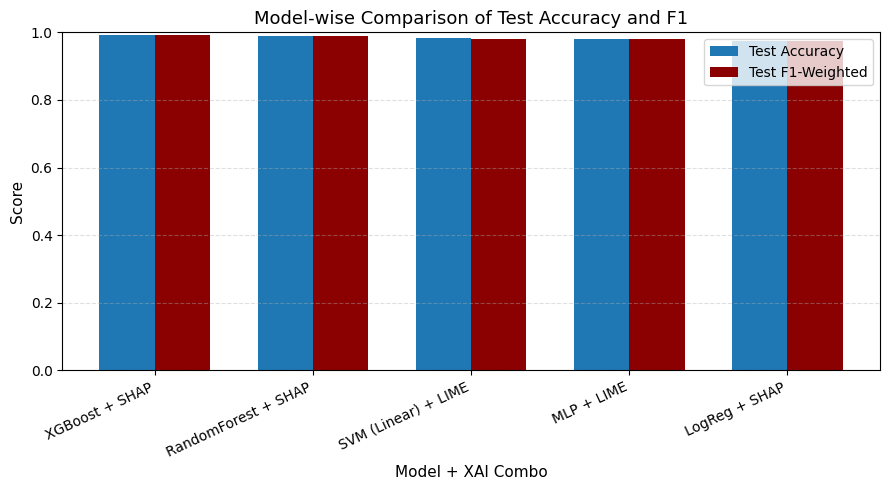

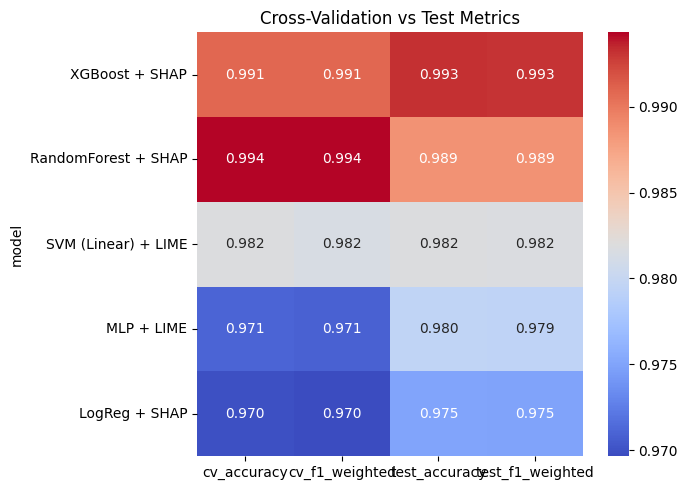

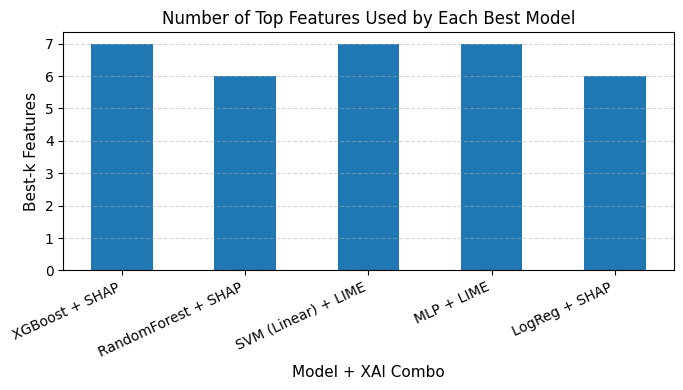

In [30]:

# Visualization Section (Two-Color Research Style)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1 — Comparison of Test Accuracy and F1 across models
x = np.arange(len(summary_df["model"]))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, summary_df["test_accuracy"],
        width=width, label="Test Accuracy", color="#1f77b4")   # blue
plt.bar(x + width/2, summary_df["test_f1_weighted"],
        width=width, label="Test F1-Weighted", color="#8B0000") # orange

plt.title("Model-wise Comparison of Test Accuracy and F1", fontsize=13)
plt.xlabel("Model + XAI Combo", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.xticks(x, summary_df["model"], rotation=25, ha='right')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Plot 2 — Cross-Validation vs Test Performance Heatmap
plt.figure(figsize=(7,5))
perf_cols = ["cv_accuracy", "cv_f1_weighted", "test_accuracy", "test_f1_weighted"]
sns.heatmap(summary_df.set_index("model")[perf_cols],
            annot=True, fmt=".3f", cmap="coolwarm", cbar=True)
plt.title("Cross-Validation vs Test Metrics", fontsize=12)
plt.tight_layout()
plt.show()

# Plot 3 — Best-k Features per Model
plt.figure(figsize=(7,4))
plt.bar(summary_df["model"], summary_df["best_k"],
        color="#1f77b4", width=0.5)
plt.title("Number of Top Features Used by Each Best Model", fontsize=12)
plt.xlabel("Model + XAI Combo", fontsize=11)
plt.ylabel("Best-k Features", fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#Case 1 extended ensembling of ml models

Collecting feature importance and model weights



In [31]:
# Weighted Average Feature Importance — Step 1: Collect & Normalize
import pandas as pd
import numpy as np

# dictionary: model_name -> (feature_importance_series, test_f1_weighted)
feature_sets = {
    "LogReg":  (feature_importance,                 baseline_results_df.loc[baseline_results_df['model']=="Logistic Regression","test_f1_weighted"].values[0]),
    "XGB":     (feature_importance_xgb,             baseline_results_df.loc[baseline_results_df['model']=="XGBoost","test_f1_weighted"].values[0]),
    "RF":      (feature_importance_rf,              baseline_results_df.loc[baseline_results_df['model']=="Random Forest","test_f1_weighted"].values[0]),
    "SVM":     (feature_importance_lime,            baseline_results_df.loc[baseline_results_df['model']=="SVM (Linear)","test_f1_weighted"].values[0]),
    "MLP":     (feature_importance_lime_mlp,        baseline_results_df.loc[baseline_results_df['model']=="MLPClassifier","test_f1_weighted"].values[0])
}

# normalize feature importance per model (sum = 1)
norm_feats = {}
for name, (imp, _) in feature_sets.items():
    imp_norm = imp / imp.sum()
    norm_feats[name] = imp_norm

# put all into one DataFrame
feat_df = pd.DataFrame(norm_feats).fillna(0)
display(feat_df.head())


,LogReg,XGB,RF,SVM,MLP
K,0.195965,0.112051,0.182598,0.057892,0.038812
N,0.141655,0.133678,0.171002,0.262299,0.275081
P,0.196409,0.183194,0.158711,0.303876,0.279879
humidity,0.163956,0.245845,0.213236,0.108770,0.121341
ph,0.046455,0.032742,0.033613,0.123150,0.120062


Compute weighted ensemble importand and per model vs weighted importance

✅ Weighted Average Feature Importance (Top 10):


,0
P,0.224038
N,0.196294
humidity,0.171011
rainfall,0.150368
K,0.117888
ph,0.070891
temperature,0.069511


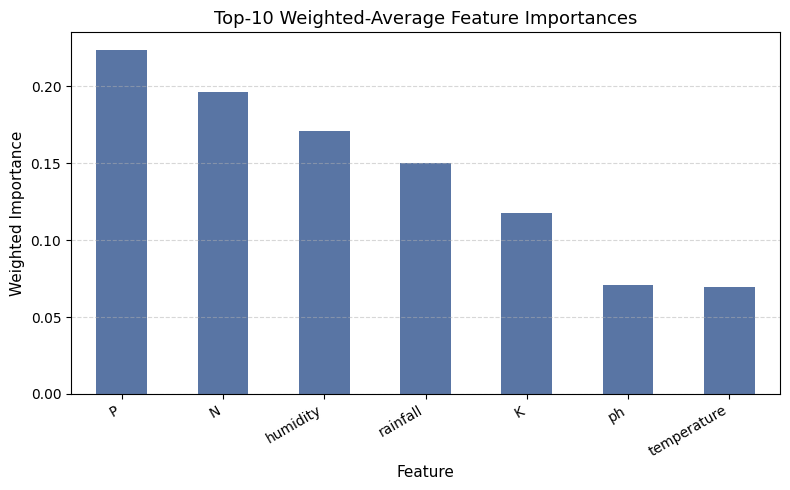

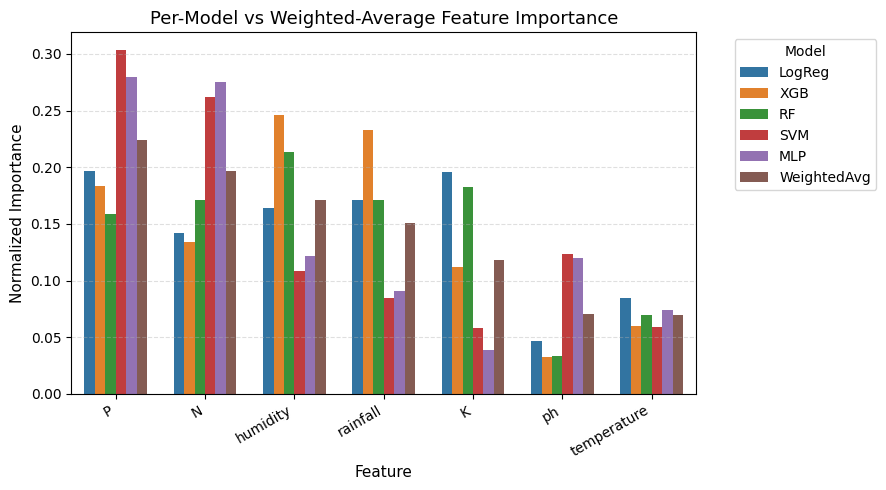

In [32]:
#  Step 2: Compute Weighted Average Importance
weights = {m: f1 for m, (_, f1) in feature_sets.items()}
total_weight = sum(weights.values())

# Weighted mean across models
weighted_importance = sum(feat_df[m] * weights[m] for m in feat_df.columns) / total_weight
weighted_importance = weighted_importance.sort_values(ascending=False)

print("✅ Weighted Average Feature Importance (Top 10):")
display(weighted_importance.head(10))

#  Plot 1: Weighted Importance Bar Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=weighted_importance.head(10).index,
            y=weighted_importance.head(10).values,
            color="#4c72b0", width=0.5)
plt.title("Top-10 Weighted-Average Feature Importances", fontsize=13)
plt.xlabel("Feature", fontsize=11)
plt.ylabel("Weighted Importance", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Step 3: Compare Model-wise vs Weighted Ensemble Importance
top_feats = weighted_importance.head(7).index
compare_df = feat_df.loc[top_feats].copy()
compare_df["WeightedAvg"] = weighted_importance.loc[top_feats]

compare_df_melted = compare_df.reset_index().melt(id_vars="index",
                                                  var_name="Model",
                                                  value_name="Normalized Importance")
plt.figure(figsize=(9,5))
sns.barplot(data=compare_df_melted,
            x="index", y="Normalized Importance", hue="Model", width=0.7)
plt.title("Per-Model vs Weighted-Average Feature Importance", fontsize=13)
plt.xlabel("Feature", fontsize=11)
plt.ylabel("Normalized Importance", fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Model", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


Voting ensemble algos

,Ensemble,CV Acc,CV F1,Test Acc,Test F1
0,Hard,0.985795,0.985687,0.986364,0.986269
1,Soft,0.992045,0.992567,0.995455,0.995452
2,WeightedSoft,0.992045,0.992567,0.995455,0.995452


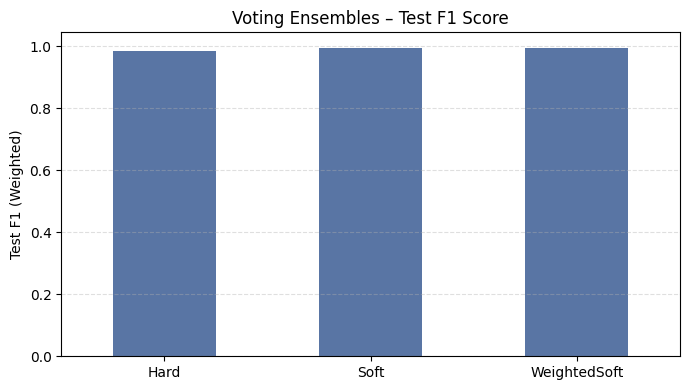

In [33]:
# Case 1 Ensemble A — Voting (Hard / Soft / Weighted)
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

#  Base learners
def make_logreg():  return Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))])
def make_xgb():     return XGBClassifier(eval_metric="mlogloss", random_state=42)
def make_rf():      return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
def make_svm():     return Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="linear", probability=True))])
def make_mlp():     return Pipeline([("scaler", StandardScaler()),
                                     ("clf", MLPClassifier(hidden_layer_sizes=(128,64), max_iter=1000,
                                                           early_stopping=True, validation_fraction=0.1,
                                                           random_state=42))])

base_models = {
    "LogReg": make_logreg(),
    "XGB":    make_xgb(),
    "RF":     make_rf(),
    "SVM":    make_svm(),
    "MLP":    make_mlp()
}
estimators_list = [(k,v) for k,v in base_models.items()]

#  Use top weighted-avg features
top_feats = weighted_importance.index
Xtr, Xte = X_train[top_feats], X_test[top_feats]

#  Case 1 test F1 as weights
weights_soft = baseline_results_df.set_index("model")["test_f1_weighted"].to_dict()
weights_soft = [weights_soft.get(name_map, 1.0) for name_map in
                ["Logistic Regression","XGBoost","Random Forest","SVM (Linear)","MLPClassifier"]]

#  Evaluate three voting modes
results_vote = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for mode, w in [("Hard",None), ("Soft",None), ("WeightedSoft",weights_soft)]:
    vc = VotingClassifier(estimators=estimators_list, voting="soft" if "Soft" in mode else "hard", weights=w)
    acc_cv = cross_val_score(vc, Xtr, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1_cv  = cross_val_score(vc, Xtr, y_train_encoded, scoring="f1_weighted", cv=cv).mean()
    vc.fit(Xtr, y_train_encoded)
    y_pred = vc.predict(Xte)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1_te  = f1_score(y_test_encoded, y_pred, average="weighted")
    results_vote.append({"Ensemble":mode,"CV Acc":acc_cv,"CV F1":f1_cv,"Test Acc":acc_te,"Test F1":f1_te})

results_vote_df = pd.DataFrame(results_vote)
display(results_vote_df)

#  Plot
plt.figure(figsize=(7,4))
sns.barplot(data=results_vote_df, x="Ensemble", y="Test F1", color="#4c72b0", width=0.25)
plt.title("Voting Ensembles – Test F1 Score", fontsize=12)
plt.ylabel("Test F1 (Weighted)"); plt.xlabel("")
plt.grid(axis='y', linestyle='--', alpha=0.4); plt.tight_layout(); plt.show()


Plot fix

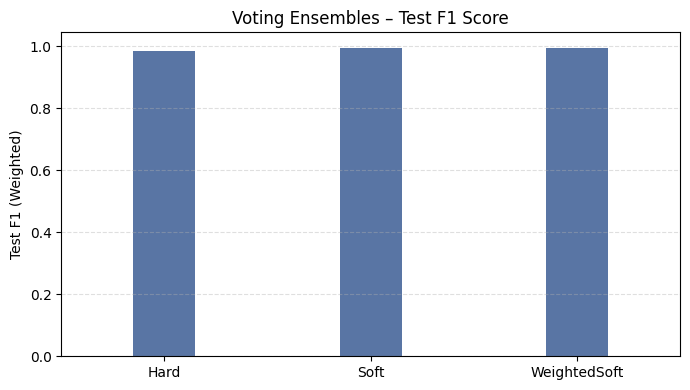

In [35]:

#  Plot
plt.figure(figsize=(7,4))
sns.barplot(data=results_vote_df, x="Ensemble", y="Test F1", color="#4c72b0", width=0.30)
plt.title("Voting Ensembles – Test F1 Score", fontsize=12)
plt.ylabel("Test F1 (Weighted)"); plt.xlabel("")
plt.grid(axis='y', linestyle='--', alpha=0.4); plt.tight_layout(); plt.show()

Stacking ensemble

✅ Stacking Accuracy = 0.9955 | F1 = 0.9955


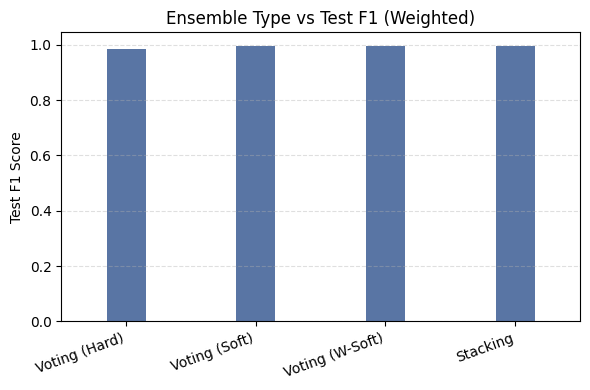

In [37]:
#  Case 1 Ensemble B — Stacking
from sklearn.ensemble import StackingClassifier

stack_ensemble = StackingClassifier(
    estimators=estimators_list,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1
)
stack_ensemble.fit(Xtr, y_train_encoded)
y_pred_stack = stack_ensemble.predict(Xte)

acc_stack = accuracy_score(y_test_encoded, y_pred_stack)
f1_stack = f1_score(y_test_encoded, y_pred_stack, average="weighted")

print(f"✅ Stacking Accuracy = {acc_stack:.4f} | F1 = {f1_stack:.4f}")

#  Simple comparison bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=["Voting (Hard)","Voting (Soft)","Voting (W-Soft)","Stacking"],
            y=list(results_vote_df["Test F1"]) + [f1_stack],
            color="#4c72b0", width=0.3)
plt.title("Ensemble Type vs Test F1 (Weighted)", fontsize=12)
plt.ylabel("Test F1 Score"); plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4); plt.tight_layout(); plt.show()


Blending ensemble

✅ Blending Accuracy = 0.9955 | F1 = 0.9955


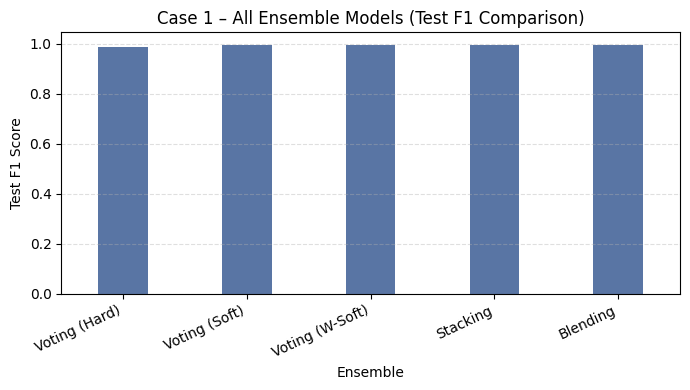

,Ensemble,Test F1
0,Voting (Hard),0.986269
1,Voting (Soft),0.995452
2,Voting (W-Soft),0.995452
3,Stacking,0.995452
4,Blending,0.995452


In [38]:
#  Case 1 Ensemble C — Blending
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

X_base, X_meta, y_base, y_meta = train_test_split(Xtr, y_train_encoded,
                                                  test_size=0.2, stratify=y_train_encoded, random_state=42)

meta_train = []
meta_test  = []

for name, est in base_models.items():
    est.fit(X_base, y_base)
    meta_train.append(est.predict_proba(X_meta))
    meta_test.append(est.predict_proba(Xte))

Z_valid = np.concatenate(meta_train, axis=1)
Z_test  = np.concatenate(meta_test, axis=1)

meta_lr = LogisticRegression(max_iter=3000)
meta_lr.fit(Z_valid, y_meta)
y_pred_blend = meta_lr.predict(Z_test)

acc_blend = accuracy_score(y_test_encoded, y_pred_blend)
f1_blend  = f1_score(y_test_encoded, y_pred_blend, average="weighted")

print(f"✅ Blending Accuracy = {acc_blend:.4f} | F1 = {f1_blend:.4f}")

# Final ensemble comparison plot
ensemble_summary = pd.DataFrame({
    "Ensemble": ["Voting (Hard)","Voting (Soft)","Voting (W-Soft)","Stacking","Blending"],
    "Test F1": list(results_vote_df["Test F1"]) + [f1_stack, f1_blend]
})

plt.figure(figsize=(7,4))
sns.barplot(data=ensemble_summary, x="Ensemble", y="Test F1", color="#4c72b0", width=0.4)
plt.title("Case 1 – All Ensemble Models (Test F1 Comparison)", fontsize=12)
plt.ylabel("Test F1 Score"); plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

display(ensemble_summary)


Final summary plot

✅ Final Case 1 Ensemble Performance Summary (Highest F1 on top):


,Ensemble,Test Accuracy,Test F1
0,Voting (Soft),0.995455,0.995452
1,Stacking,0.995455,0.995452
2,Voting (W-Soft),0.995455,0.995452
3,Blending,0.995455,0.995452
4,Voting (Hard),0.986364,0.986269


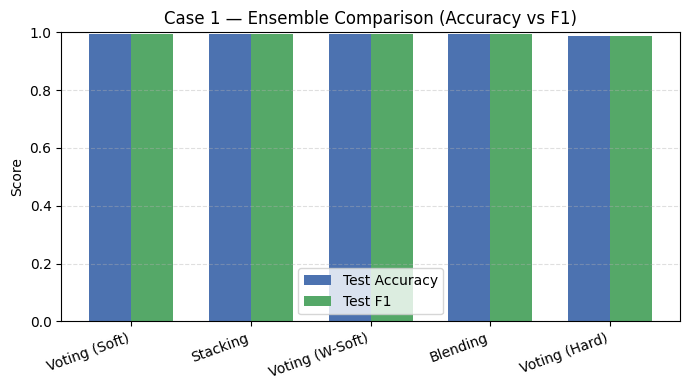

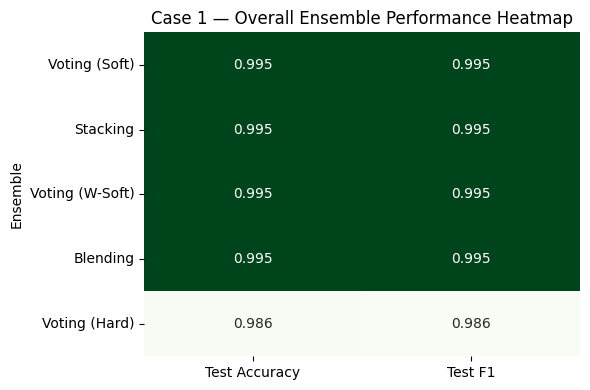

🏆 Champion Ensemble: Voting (Soft) | Accuracy = 0.9955 | F1 = 0.9955


In [39]:
#  Case 1 — Final Summary and Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the final DataFrame exists
ensemble_summary["Test Accuracy"] = [
    results_vote_df.loc[results_vote_df["Ensemble"]=="Hard","Test Acc"].values[0],
    results_vote_df.loc[results_vote_df["Ensemble"]=="Soft","Test Acc"].values[0],
    results_vote_df.loc[results_vote_df["Ensemble"]=="WeightedSoft","Test Acc"].values[0],
    acc_stack,
    acc_blend
]

# Reorder for clarity
ensemble_summary = ensemble_summary[["Ensemble","Test Accuracy","Test F1"]]

#  Sort by Test F1 descending
ensemble_summary = ensemble_summary.sort_values(by="Test F1", ascending=False).reset_index(drop=True)

print("✅ Final Case 1 Ensemble Performance Summary (Highest F1 on top):")
display(ensemble_summary)

# Plot 1: Side-by-side Accuracy & F1
plt.figure(figsize=(7,4))
bar_w = 0.35
x = np.arange(len(ensemble_summary))
plt.bar(x - bar_w/2, ensemble_summary["Test Accuracy"], width=bar_w, color="#4C72B0", label="Test Accuracy")
plt.bar(x + bar_w/2, ensemble_summary["Test F1"], width=bar_w, color="#55A868", label="Test F1")
plt.xticks(x, ensemble_summary["Ensemble"], rotation=20, ha='right')
plt.title("Case 1 — Ensemble Comparison (Accuracy vs F1)", fontsize=12)
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#  Plot 2: Heatmap of Performance Metrics
plt.figure(figsize=(6,4))
sns.heatmap(ensemble_summary.set_index("Ensemble"), annot=True, fmt=".3f",
            cmap="Greens", cbar=False)
plt.title("Case 1 — Overall Ensemble Performance Heatmap", fontsize=12)
plt.tight_layout()
plt.show()

#  Highlight Champion Ensemble
champion = ensemble_summary.iloc[0]
print(f"🏆 Champion Ensemble: {champion['Ensemble']} | Accuracy = {champion['Test Accuracy']:.4f} | F1 = {champion['Test F1']:.4f}")


#Case 2 Ensemble feature selection + individual models
Normalise the feature importance scales for all the previous models

✅ Normalized feature importance vectors (sum=1 per model):


,LogReg,XGB,RF,SVM,MLP
K,0.1960,0.1121,0.1826,0.0579,0.0388
N,0.1417,0.1337,0.1710,0.2623,0.2751
P,0.1964,0.1832,0.1587,0.3039,0.2799
humidity,0.1640,0.2458,0.2132,0.1088,0.1213
ph,0.0465,0.0327,0.0336,0.1232,0.1201
rainfall,0.1707,0.2325,0.1713,0.0848,0.0906
temperature,0.0848,0.0600,0.0695,0.0593,0.0742


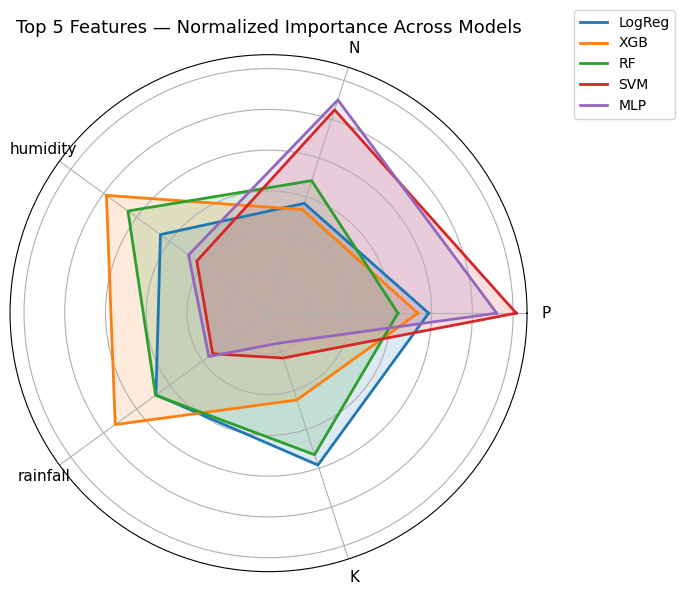

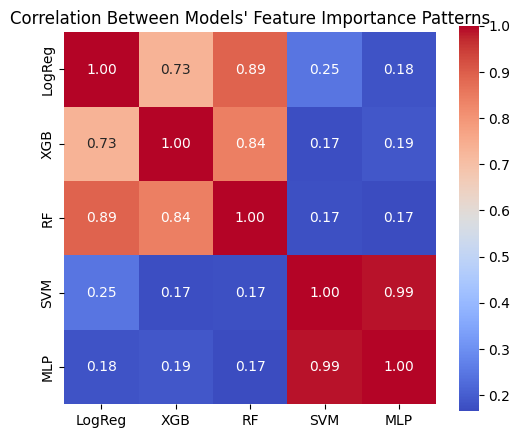

/tmp/ipython-input-3986023367.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_importance.index, y=mean_importance.values, palette="viridis")


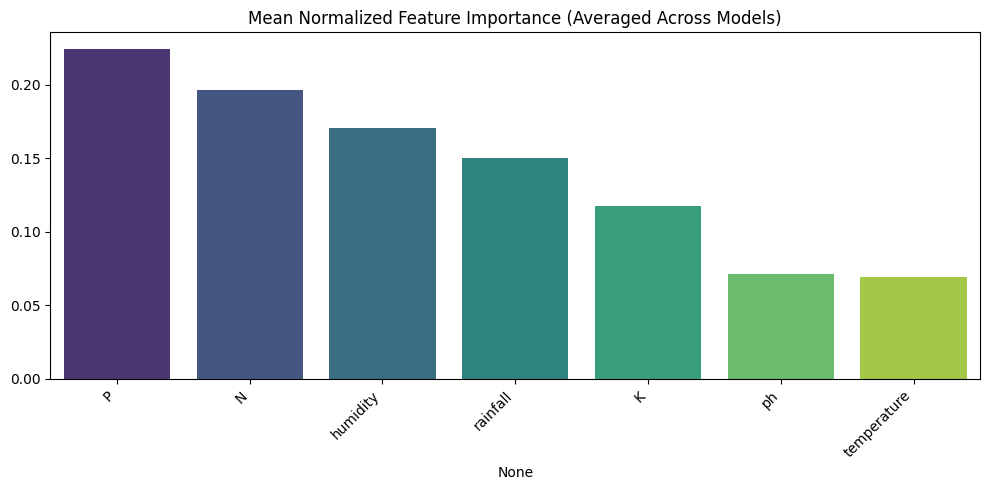

In [40]:
# Case 2: Step 1 - Normalize feature importance vectors (with plots)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

#  Normalization Function
def normalize_importance(series: pd.Series, method="sum"):
    """
    Normalize a pandas Series of feature importances.
    - method="sum": each feature importance divided by sum → vector sums to 1
    - method="max": each feature importance divided by max → max=1
    """
    s = series.abs().copy()
    if method == "sum":
        return s / s.sum()
    elif method == "max":
        return s / s.max()
    else:
        raise ValueError("method must be 'sum' or 'max'")

#  Normalize Each Model’s Importance
logreg_norm = normalize_importance(feature_importance, method="sum")
xgb_norm    = normalize_importance(feature_importance_xgb, method="sum")
rf_norm     = normalize_importance(feature_importance_rf, method="sum")
svm_norm    = normalize_importance(feature_importance_lime, method="sum")
mlp_norm    = normalize_importance(feature_importance_lime_mlp, method="sum")

#  Combine into a DataFrame
ensemble_norm_df = pd.DataFrame({
    "LogReg": logreg_norm,
    "XGB": xgb_norm,
    "RF": rf_norm,
    "SVM": svm_norm,
    "MLP": mlp_norm
}).fillna(0)

print("✅ Normalized feature importance vectors (sum=1 per model):")
display(ensemble_norm_df.round(4))


#  Radar Plot for Top 5 Features
top_features = ensemble_norm_df.mean(axis=1).sort_values(ascending=False).head(5).index
subset = ensemble_norm_df.loc[top_features]

# Radar setup
labels = list(subset.index)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model in subset.columns:
    values = subset.loc[:, model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, linewidth=2)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels([])
plt.title("Top 5 Features — Normalized Importance Across Models", fontsize=13)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

#  Correlation Heatmap Between Models
corr = ensemble_norm_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Between Models' Feature Importance Patterns")
plt.show()

# Optional Bar Plot of Mean Normalized Importance
mean_importance = ensemble_norm_df.mean(axis=1).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=mean_importance.index, y=mean_importance.values, palette="viridis")
plt.title("Mean Normalized Feature Importance (Averaged Across Models)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#Ensemble feature methods and rankings
This does ranking of ensemble explainable techniques applied on individual models using different ensemble brute force techniques like simple average, rank aggregation and accuracy weighted averaging

✅ Ensemble Feature Rankings (Top 10):

--- Simple Average ---


,0
P,0.224414
N,0.196743
humidity,0.170630
rainfall,0.149980
K,0.117463
ph,0.071205
temperature,0.069565



--- Rank Aggregation (lower = better rank) ---


,0
P,2.2
humidity,2.6
N,3.4
rainfall,3.6
K,4.6
ph,5.6
temperature,6.0



--- Accuracy-Weighted Average ---


,0
P,0.223971
N,0.196420
humidity,0.171092
rainfall,0.150376
K,0.117689
ph,0.070908
temperature,0.069545


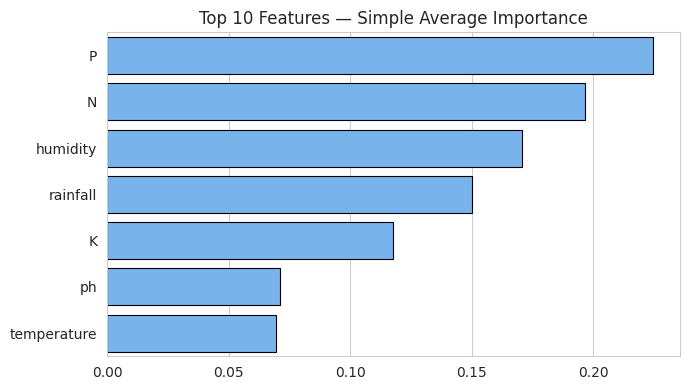

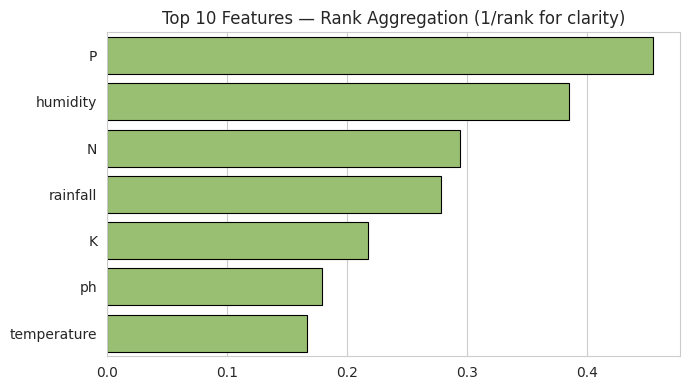

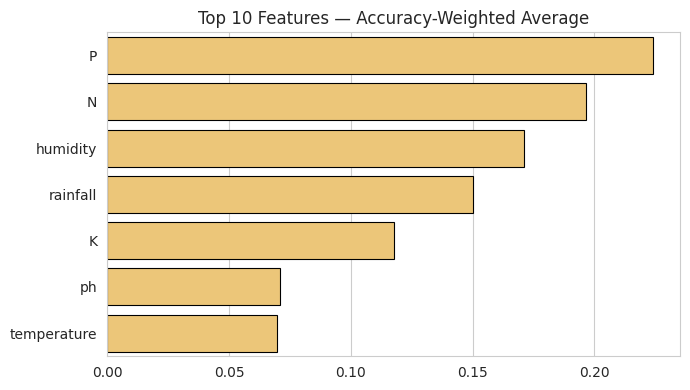

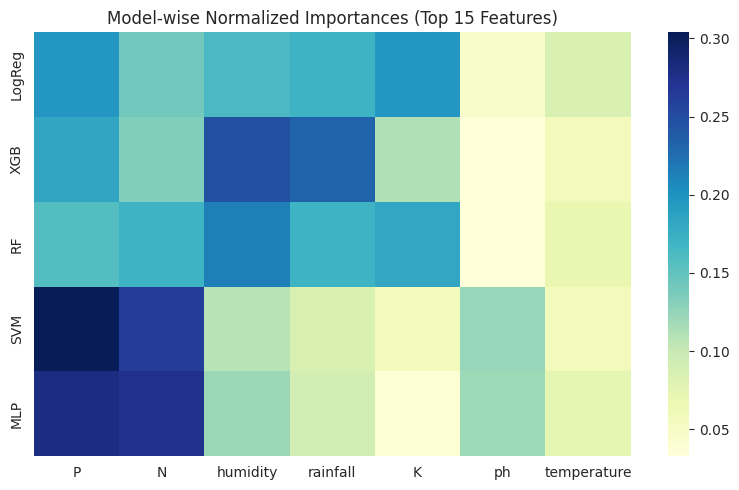

In [41]:
#  Case 2: Step 2 - Build Ensemble Feature Rankings (with visualizations)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Simple Average
ensemble_simple_avg = ensemble_norm_df.mean(axis=1).sort_values(ascending=False)

# 2️⃣ Rank Aggregation (average rank)
ranks_df = ensemble_norm_df.rank(ascending=False, method="average")
ensemble_rank_avg = ranks_df.mean(axis=1).sort_values(ascending=True)  # lower = better

# 3️⃣ Accuracy-Weighted Average
case1_test_acc = {
    "LogReg": 0.975,
    "XGB":    0.993,
    "RF":     0.995,
    "SVM":    0.970,
    "MLP":    0.980
}
weights = pd.Series(case1_test_acc)[ensemble_norm_df.columns]
ensemble_acc_weighted = (ensemble_norm_df * weights).sum(axis=1) / weights.sum()
ensemble_acc_weighted = ensemble_acc_weighted.sort_values(ascending=False)

#  Display Rankings
print("✅ Ensemble Feature Rankings (Top 10):")

print("\n--- Simple Average ---")
display(ensemble_simple_avg.head(10))

print("\n--- Rank Aggregation (lower = better rank) ---")
display(ensemble_rank_avg.head(10))

print("\n--- Accuracy-Weighted Average ---")
display(ensemble_acc_weighted.head(10))





sns.set_style("whitegrid")

# helper to make narrow barplots
def narrow_barplot(series, title, color):
    plt.figure(figsize=(7,4))
    sns.barplot(
        x=series.head(10).values,
        y=series.head(10).index,
        orient="h",
        color=color,
        edgecolor="black",
        linewidth=0.8
    )
    plt.title(title, fontsize=12)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

#  Simple Average Plot
narrow_barplot(ensemble_simple_avg, "Top 10 Features — Simple Average Importance", "#66b3ff")

#  Rank Aggregation Plot (invert ranks for clearer bars)
inv_rank = (1 / ensemble_rank_avg).sort_values(ascending=False)
narrow_barplot(inv_rank, "Top 10 Features — Rank Aggregation (1/rank for clarity)", "#99cc66")

#  Accuracy-Weighted Average Plot
narrow_barplot(ensemble_acc_weighted, "Top 10 Features — Accuracy-Weighted Average", "#ffcc66")

# Optional Comparison Heatmap of Top 15 Features
top15_feats = ensemble_acc_weighted.head(15).index
plt.figure(figsize=(8,5))
sns.heatmap(ensemble_norm_df.loc[top15_feats].T, cmap="YlGnBu", annot=False)
plt.title("Model-wise Normalized Importances (Top 15 Features)")
plt.tight_layout()
plt.show()


#Helper functions
The feature rankings via different aggregation strategies help us now for using those top k ranked features for model training and evaluating the best combinations

,strategy,k_features,features_used,model,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,AccWeighted,1,[P],LogReg,0.203409,0.151072,0.190909,0.139977
1,AccWeighted,2,"[P, N]",LogReg,0.394886,0.376064,0.390909,0.373221
2,AccWeighted,3,"[P, N, humidity]",LogReg,0.803977,0.797820,0.797727,0.793026
3,AccWeighted,4,"[P, N, humidity, rainfall]",LogReg,0.921023,0.920428,0.931818,0.931906
4,AccWeighted,5,"[P, N, humidity, rainfall, K]",LogReg,0.963636,0.963209,0.975000,0.974896
5,AccWeighted,6,"[P, N, humidity, rainfall, K, ph]",LogReg,0.961932,0.961443,0.984091,0.983933
6,AccWeighted,7,"[P, N, humidity, rainfall, K, ph, temperature]",LogReg,0.968182,0.967824,0.972727,0.972464
7,AccWeighted,1,[P],MLP,0.192045,0.111443,0.215909,0.137962
8,AccWeighted,2,"[P, N]",MLP,0.411932,0.375372,0.411364,0.402222
9,AccWeighted,3,"[P, N, humidity]",MLP,0.792614,0.784661,0.820455,0.816860


,strategy,model,best_k,cv_acc,cv_f1,test_acc,test_f1
0,AccWeighted,RF,7,0.995455,0.995433,0.995455,0.995452
1,SimpleAvg,RF,7,0.995455,0.995433,0.995455,0.995452
2,RankAvg,RF,7,0.994886,0.994854,0.993182,0.993178
3,AccWeighted,XGB,7,0.991477,0.991444,0.993182,0.993116
4,RankAvg,XGB,7,0.990341,0.990306,0.993182,0.993116
5,SimpleAvg,XGB,7,0.991477,0.991444,0.993182,0.993116
6,AccWeighted,SVM,6,0.981818,0.981498,0.990909,0.990817
7,RankAvg,SVM,6,0.981818,0.981498,0.990909,0.990817
8,SimpleAvg,SVM,6,0.981818,0.981498,0.990909,0.990817
9,RankAvg,MLP,7,0.964773,0.964645,0.986364,0.986321


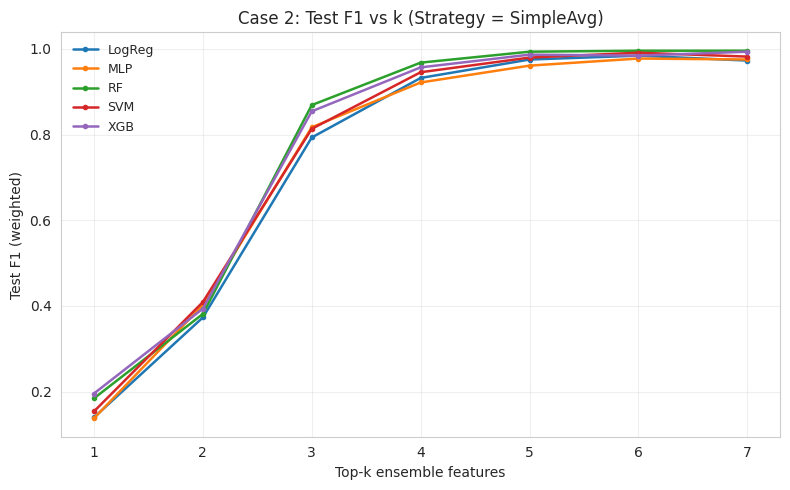

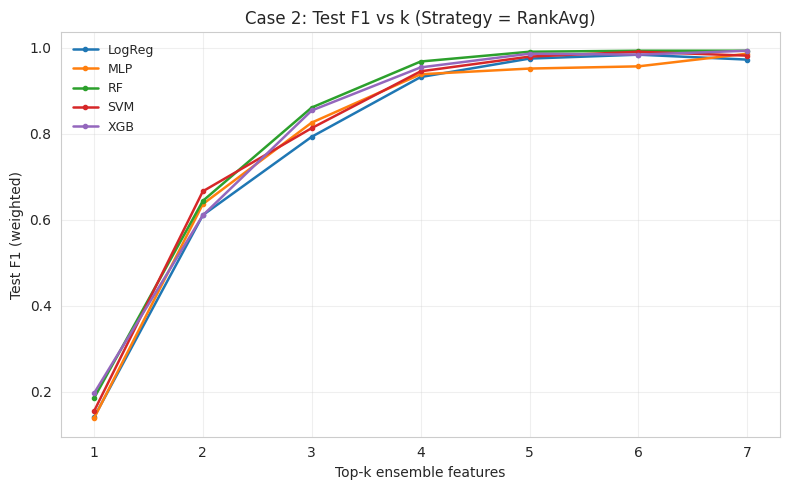

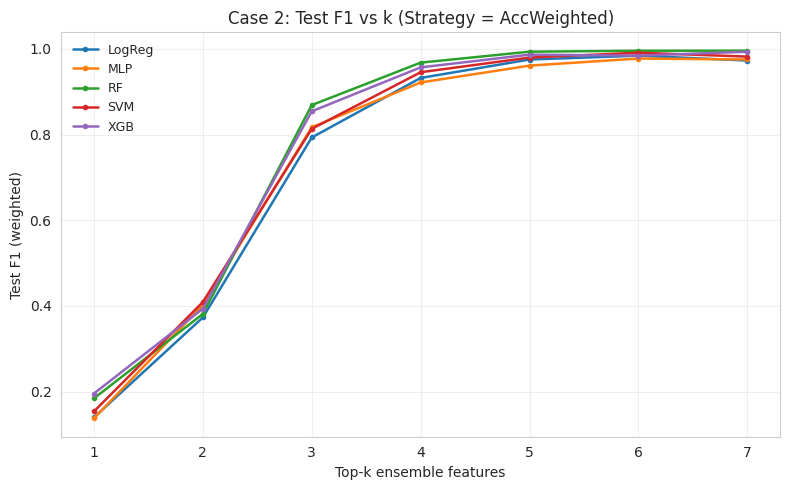

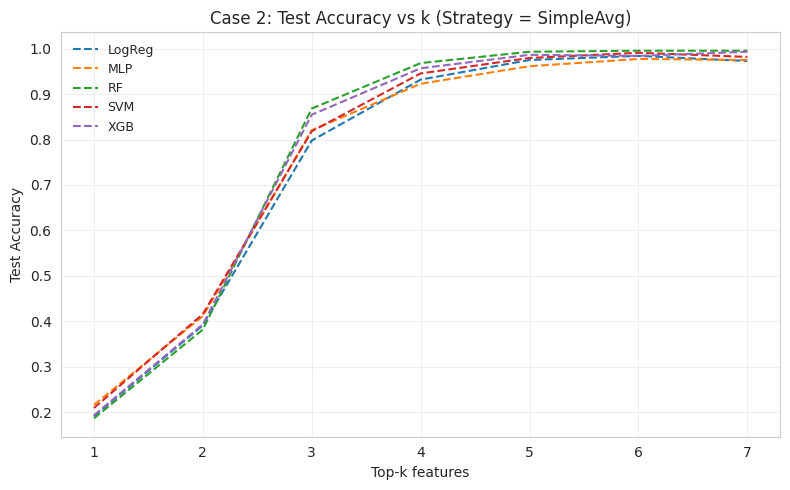

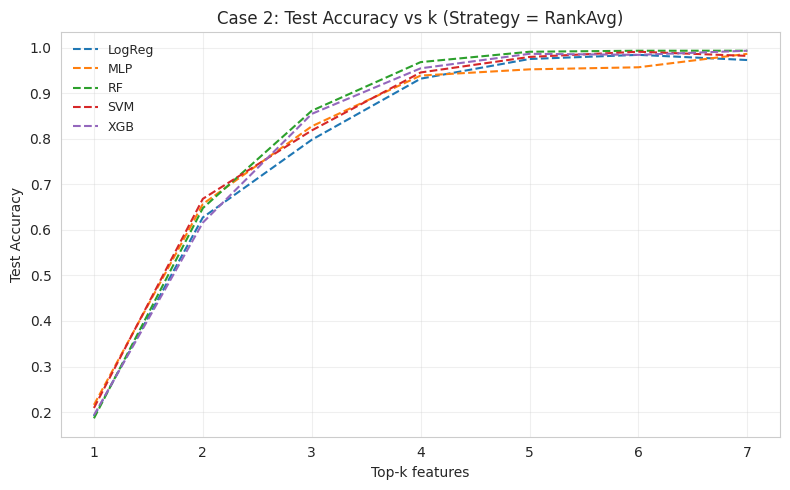

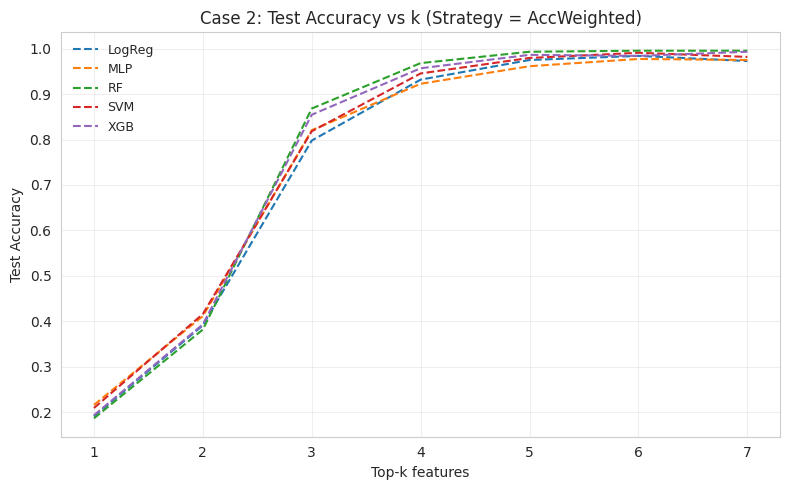

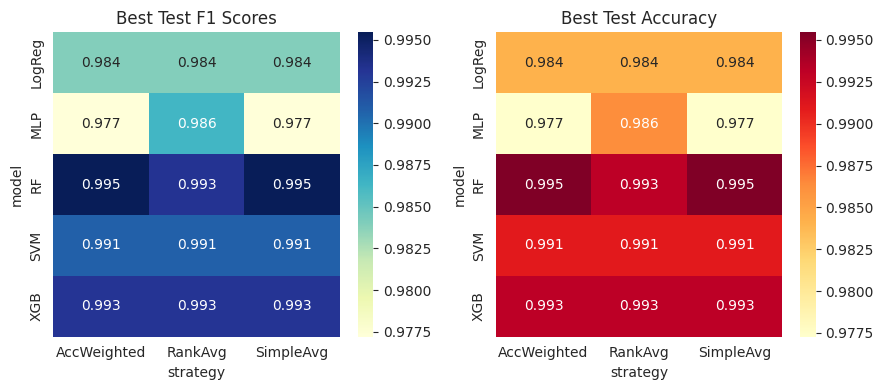

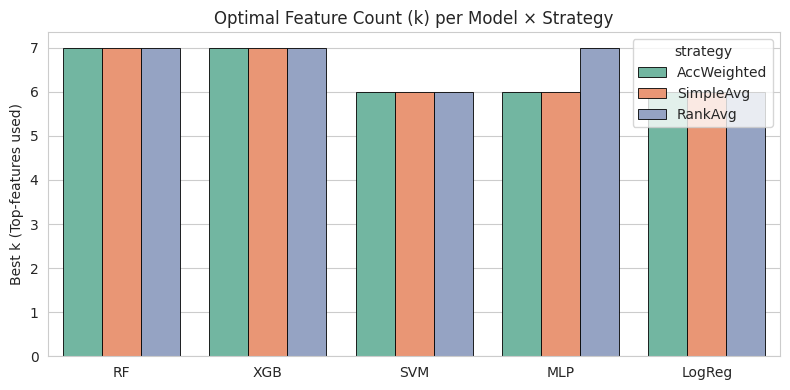

In [43]:
# Case 2: Step 3 — Train all models on ensemble feature rankings (with plots)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone




def make_logreg(): return Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs"))
])
def make_xgb():
    try: return XGBClassifier(**xgb.get_xgb_params())
    except: return XGBClassifier(
        eval_metric="mlogloss", random_state=42, n_estimators=300,
        learning_rate=0.1, max_depth=6, subsample=0.9, colsample_bytree=0.9)
def make_rf():
    try: return clone(rf)
    except: return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
def make_svm(): return Pipeline([
    ("scaler", StandardScaler()), ("clf", SVC(kernel="linear"))])
def make_mlp(): return Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000,
                          early_stopping=True, n_iter_no_change=20,
                          validation_fraction=0.1, random_state=42))])
MODELS = {"LogReg": make_logreg, "XGB": make_xgb, "RF": make_rf, "SVM": make_svm, "MLP": make_mlp}




def run_topk_for_strategy(strategy_name: str, feature_series: pd.Series):
    if strategy_name == "RankAvg":
        ordered_features = list(feature_series.sort_values(ascending=True).index)
    else:
        ordered_features = list(feature_series.sort_values(ascending=False).index)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rows = []
    for k in range(1, len(ordered_features) + 1):
        feats = [f for f in ordered_features[:k] if f in X_train.columns]
        if not feats: continue
        Xtr_k, Xte_k = X_train[feats], X_test[feats]
        for model_name, maker in MODELS.items():
            model = maker()
            acc_cv = cross_val_score(model, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
            f1w_cv = cross_val_score(model, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()
            model.fit(Xtr_k, y_train_encoded)
            y_pred = model.predict(Xte_k)
            acc_te = accuracy_score(y_test_encoded, y_pred)
            f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")
            rows.append({
                "strategy": strategy_name, "k_features": k, "features_used": feats,
                "model": model_name, "cv_accuracy": acc_cv, "cv_f1_weighted": f1w_cv,
                "test_accuracy": acc_te, "test_f1_weighted": f1w_te})
    return pd.DataFrame(rows)


results_case2_simple = run_topk_for_strategy("SimpleAvg", ensemble_simple_avg)
results_case2_rank   = run_topk_for_strategy("RankAvg",   ensemble_rank_avg)
results_case2_accw   = run_topk_for_strategy("AccWeighted", ensemble_acc_weighted)
results_case2_all = pd.concat([results_case2_simple, results_case2_rank, results_case2_accw], ignore_index=True)
results_case2_all = results_case2_all.sort_values(by=["strategy","model","k_features"]).reset_index(drop=True)
display(results_case2_all.head(10))




def pick_best(df):
    return (df.sort_values(
        by=["test_f1_weighted","test_accuracy","cv_f1_weighted","cv_accuracy","k_features"],
        ascending=[False,False,False,False,True]).iloc[0])
best_rows=[]
for (strategy,model),sub in results_case2_all.groupby(["strategy","model"]):
    b=pick_best(sub)
    best_rows.append({
        "strategy":strategy,"model":model,"best_k":int(b["k_features"]),
        "cv_acc":b["cv_accuracy"],"cv_f1":b["cv_f1_weighted"],
        "test_acc":b["test_accuracy"],"test_f1":b["test_f1_weighted"]})
summary_case2=pd.DataFrame(best_rows).sort_values(by=["test_f1","test_acc"],ascending=[False,False]).reset_index(drop=True)
display(summary_case2)




sns.set_style("whitegrid")

# Performance curves per strategy
for strat in ["SimpleAvg","RankAvg","AccWeighted"]:
    sub = results_case2_all[results_case2_all["strategy"]==strat]
    plt.figure(figsize=(8,5))
    for m in sub["model"].unique():
        ss=sub[sub["model"]==m]
        plt.plot(ss["k_features"], ss["test_f1_weighted"],
                 marker='.', linewidth=1.8, label=m)
    plt.title(f"Case 2: Test F1 vs k (Strategy = {strat})")
    plt.xlabel("Top-k ensemble features"); plt.ylabel("Test F1 (weighted)")
    plt.grid(True,alpha=0.3); plt.legend(frameon=False,fontsize=9)
    plt.tight_layout(); plt.show()

#  Accuracy curves (optional)
for strat in ["SimpleAvg","RankAvg","AccWeighted"]:
    sub=results_case2_all[results_case2_all["strategy"]==strat]
    plt.figure(figsize=(8,5))
    for m in sub["model"].unique():
        ss=sub[sub["model"]==m]
        plt.plot(ss["k_features"], ss["test_accuracy"],
                 linestyle="--", linewidth=1.5, label=m)
    plt.title(f"Case 2: Test Accuracy vs k (Strategy = {strat})")
    plt.xlabel("Top-k features"); plt.ylabel("Test Accuracy")
    plt.grid(True,alpha=0.3); plt.legend(frameon=False,fontsize=9)
    plt.tight_layout(); plt.show()
# Heatmap of best performance (fixed for modern pandas)
pivot_f1 = summary_case2.pivot(index="model", columns="strategy", values="test_f1")
pivot_acc = summary_case2.pivot(index="model", columns="strategy", values="test_acc")

fig, ax = plt.subplots(1, 2, figsize=(9,4))
sns.heatmap(pivot_f1, annot=True, cmap="YlGnBu", fmt=".3f", ax=ax[0])
ax[0].set_title("Best Test F1 Scores")
sns.heatmap(pivot_acc, annot=True, cmap="YlOrRd", fmt=".3f", ax=ax[1])
ax[1].set_title("Best Test Accuracy")
plt.tight_layout()
plt.show()


# Barplot of best k per model×strategy
plt.figure(figsize=(8,4))
sns.barplot(x="model", y="best_k", hue="strategy", data=summary_case2,
            palette="Set2", edgecolor="black", linewidth=0.6)
plt.title("Optimal Feature Count (k) per Model × Strategy")
plt.ylabel("Best k (Top-features used)"); plt.xlabel("")
plt.tight_layout(); plt.show()


#Case 3 - Ensemble feature selection + ensemble model
Ensemble feature selection directly used which was created in case 2 and ML models are ensembled using 3 different techniques hard voting ( absolute voting 0/1), soft voting (probability values averaged and then highest probability class chosen as prediction ) and weighted soft voting ( probability * acc of that model and then averaged out and the highest probabiliy class chosen as the answer )

✅ Case 3 — Voting Ensemble results (head):


,ranking,ensemble,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted,weights_used
0,AccWeighted,HardVote,1,[P],0.195455,0.155003,0.197727,0.151588,NaN
1,AccWeighted,HardVote,2,"[P, N]",0.410227,0.393893,0.400000,0.391710,NaN
2,AccWeighted,HardVote,3,"[P, N, humidity]",0.840341,0.837701,0.836364,0.833080,NaN
3,AccWeighted,HardVote,4,"[P, N, humidity, rainfall]",0.954545,0.953891,0.961364,0.961120,NaN
4,AccWeighted,HardVote,5,"[P, N, humidity, rainfall, K]",0.986364,0.986059,0.986364,0.986342,NaN
5,AccWeighted,HardVote,6,"[P, N, humidity, rainfall, K, ph]",0.989773,0.989688,0.990909,0.990817,NaN
6,AccWeighted,HardVote,7,"[P, N, humidity, rainfall, K, ph, temperature]",0.985795,0.985652,0.986364,0.986269,NaN
7,AccWeighted,SoftVote,1,[P],0.212500,0.203007,0.186364,0.184687,NaN
8,AccWeighted,SoftVote,2,"[P, N]",0.392045,0.387425,0.372727,0.369145,NaN
9,AccWeighted,SoftVote,3,"[P, N, humidity]",0.861932,0.859297,0.861364,0.860508,NaN


🏁 Case 3 — Best Voting Ensembles:


,ranking,ensemble,best_k,features_used,cv_acc,cv_f1,test_acc,test_f1,weights_used
0,AccWeighted,SoftVote,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.991414,0.995455,0.995452,NaN
1,AccWeighted,WeightedSoftVote,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.991414,0.995455,0.995452,"{'LogReg': 0.1992, 'XGB': 0.201, 'RF': 0.2015,..."
2,SimpleAvg,SoftVote,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.991414,0.995455,0.995452,NaN
3,SimpleAvg,WeightedSoftVote,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.991983,0.995455,0.995452,"{'LogReg': 0.1992, 'XGB': 0.201, 'RF': 0.2015,..."
4,RankAvg,SoftVote,7,"P, humidity, N, rainfall, K, ph, temperature",0.992045,0.991983,0.993182,0.993169,NaN
5,RankAvg,WeightedSoftVote,7,"P, humidity, N, rainfall, K, ph, temperature",0.992045,0.991983,0.993182,0.993169,"{'LogReg': 0.1989, 'XGB': 0.2007, 'RF': 0.2007..."
6,RankAvg,HardVote,6,"P, humidity, N, rainfall, K, ph",0.989773,0.989708,0.993182,0.993143,NaN
7,AccWeighted,HardVote,6,"P, N, humidity, rainfall, K, ph",0.989773,0.989688,0.990909,0.990817,NaN
8,SimpleAvg,HardVote,6,"P, N, humidity, rainfall, K, ph",0.989773,0.989688,0.990909,0.990817,NaN


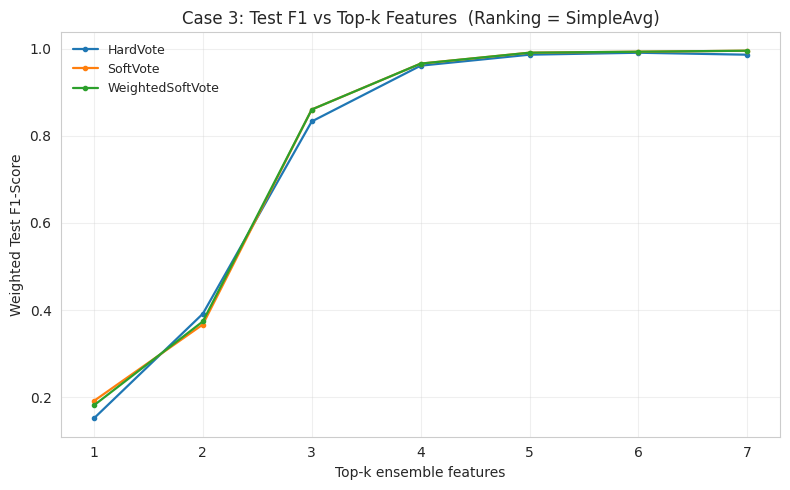

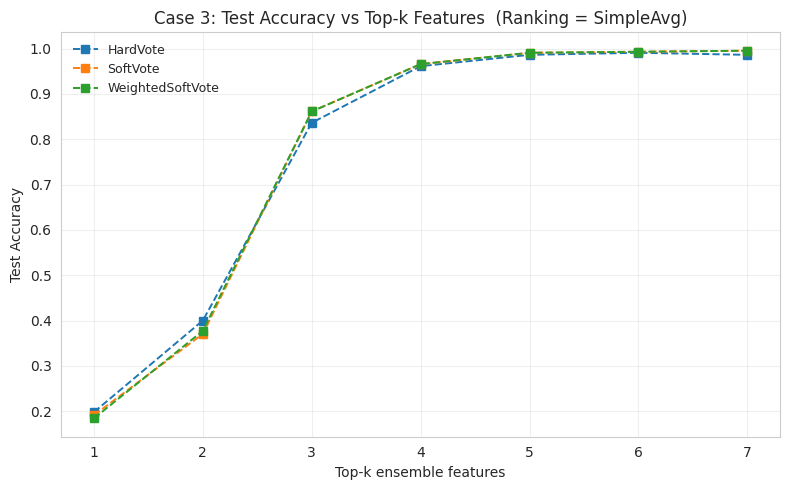

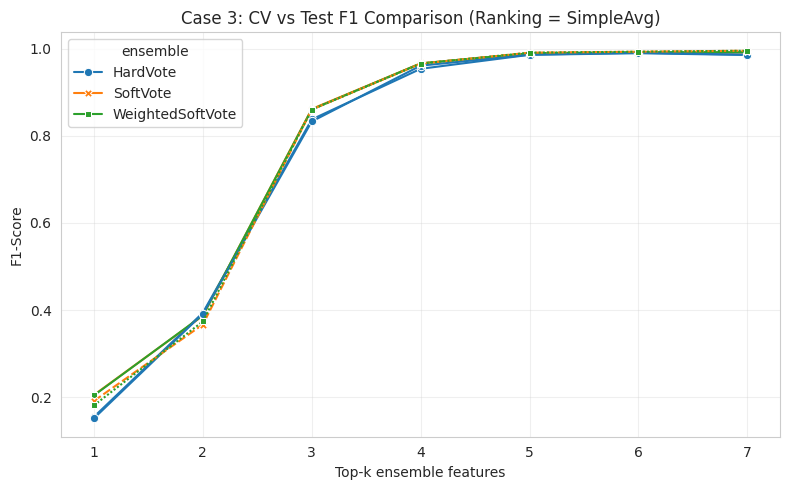

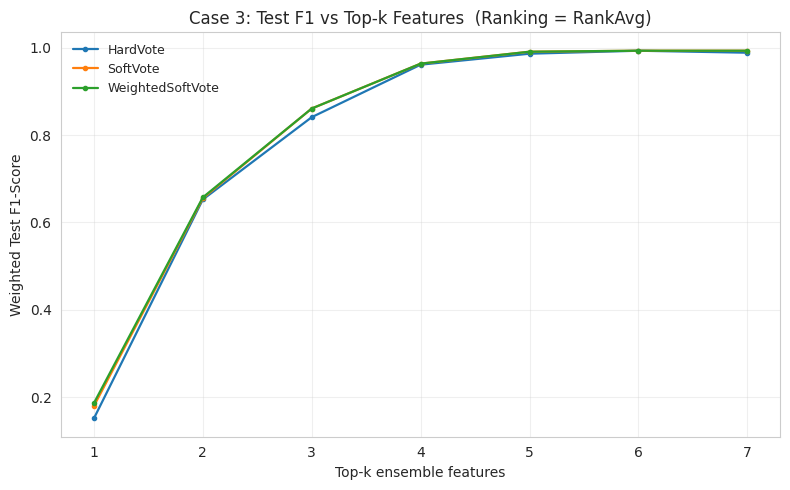

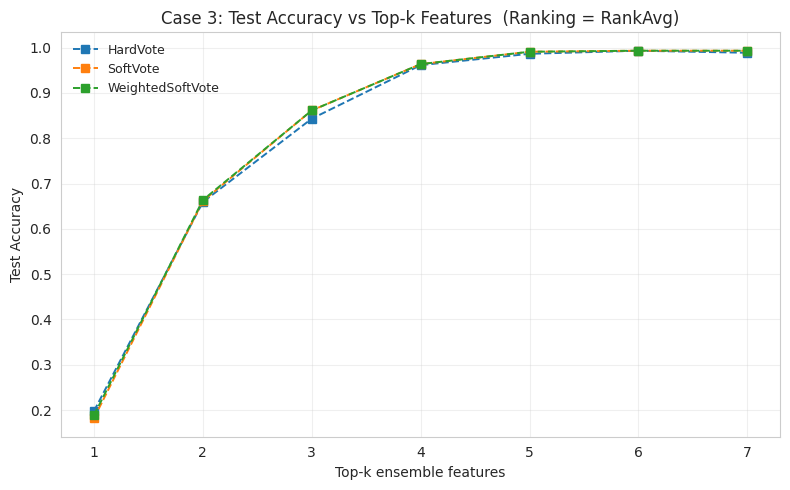

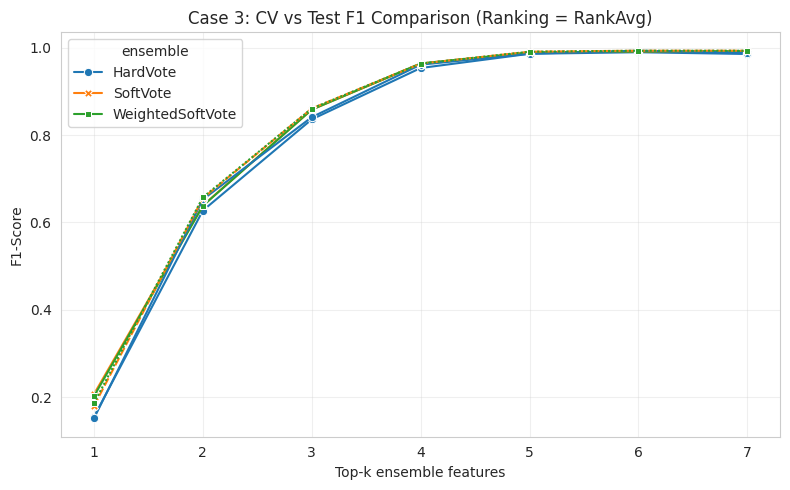

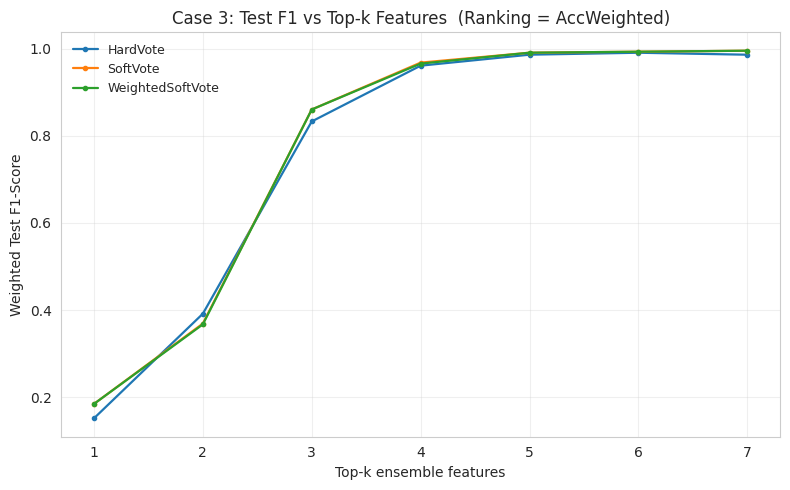

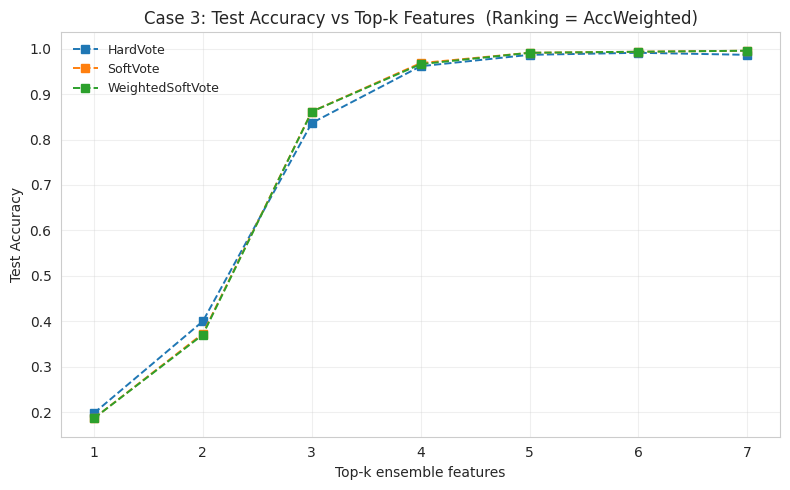

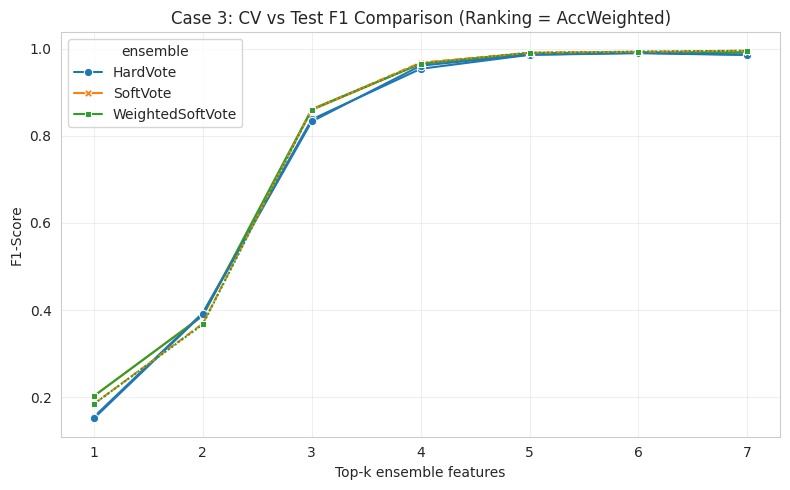

📊 Completed Case 3 / Step 1 — Voting Ensemble Visualizations


In [48]:

#  Case 3 / Step 1 — Voting Ensembles on Ensemble Feature Sets


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns

sns.set_style("whitegrid")


# X_train, X_test, y_train_encoded, y_test_encoded
# ensemble_simple_avg, ensemble_rank_avg, ensemble_acc_weighted (from Case 2)
# summary_case2 if available (for weights)





def make_logreg():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, solver="lbfgs"))
    ])

def make_xgb():
    try:
        return XGBClassifier(**xgb.get_xgb_params(), eval_metric="mlogloss")
    except:
        return XGBClassifier(
            eval_metric="mlogloss", random_state=42,
            n_estimators=300, learning_rate=0.1, max_depth=6,
            subsample=0.9, colsample_bytree=0.9
        )

def make_rf():
    try:
        return RandomForestClassifier(**rf.get_params())
    except:
        return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

def make_svm():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", probability=True))
    ])

def make_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=1000, early_stopping=True,
            n_iter_no_change=20, validation_fraction=0.1,
            random_state=42
        ))
    ])

BASE_BUILDERS = {
    "LogReg": make_logreg,
    "XGB": make_xgb,
    "RF": make_rf,
    "SVM": make_svm,
    "MLP": make_mlp,
}





RANKINGS = {
    "SimpleAvg": ensemble_simple_avg,     # higher = better
    "RankAvg": ensemble_rank_avg,         # lower = better
    "AccWeighted": ensemble_acc_weighted  # higher = better
}

def ordered_features_from_series(name: str, ser: pd.Series):
    if name == "RankAvg":
        return list(ser.sort_values(ascending=True).index)
    return list(ser.sort_values(ascending=False).index)





CASE1_TEST_ACC_FALLBACK = {
    "LogReg": 0.975, "XGB": 0.993, "RF": 0.995, "SVM": 0.970, "MLP": 0.980
}

def get_weights_for_strategy(strategy_name: str):
    weights = {}
    try:
        sub = summary_case2[summary_case2["strategy"] == strategy_name]
        if sub.empty:
            raise ValueError("No rows for strategy in summary_case2")
        for _, r in sub.iterrows():
            weights[r["model"]] = float(r["test_f1"])
    except Exception:
        weights = CASE1_TEST_ACC_FALLBACK.copy()

    # Normalize weights
    s = sum(weights.values())
    if s > 0:
        for k in weights:
            weights[k] = weights[k] / s
    return weight





def run_voting_for_ranking(rank_name: str, feats_series: pd.Series):
    ordered_feats = ordered_features_from_series(rank_name, feats_series)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rows = []

    base_models = {name: maker() for name, maker in BASE_BUILDERS.items()}
    estimators_list = [(name, mdl) for name, mdl in base_models.items()]

    w = get_weights_for_strategy(rank_name)
    weights_soft = [w.get(name, 0.0) for name in base_models.keys()]

    for k in range(1, len(ordered_feats) + 1):
        feats = [f for f in ordered_feats[:k] if f in X_train.columns and f in X_test.columns]
        if not feats:
            continue

        Xtr_k, Xte_k = X_train[feats], X_test[feats]

        # --- Hard Voting ---
        hv = VotingClassifier(estimators=estimators_list, voting="hard")
        acc_cv_h = cross_val_score(hv, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
        f1_cv_h = cross_val_score(hv, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()
        hv.fit(Xtr_k, y_train_encoded)
        y_pred_h = hv.predict(Xte_k)
        acc_te_h = accuracy_score(y_test_encoded, y_pred_h)
        f1_te_h = f1_score(y_test_encoded, y_pred_h, average="weighted")

        rows.append({
            "ranking": rank_name, "ensemble": "HardVote", "k_features": k,
            "features_used": feats, "cv_accuracy": acc_cv_h, "cv_f1_weighted": f1_cv_h,
            "test_accuracy": acc_te_h, "test_f1_weighted": f1_te_h
        })

        # Soft Voting
        sv = VotingClassifier(estimators=estimators_list, voting="soft")
        acc_cv_s = cross_val_score(sv, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
        f1_cv_s = cross_val_score(sv, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()
        sv.fit(Xtr_k, y_train_encoded)
        y_pred_s = sv.predict(Xte_k)
        acc_te_s = accuracy_score(y_test_encoded, y_pred_s)
        f1_te_s = f1_score(y_test_encoded, y_pred_s, average="weighted")

        rows.append({
            "ranking": rank_name, "ensemble": "SoftVote", "k_features": k,
            "features_used": feats, "cv_accuracy": acc_cv_s, "cv_f1_weighted": f1_cv_s,
            "test_accuracy": acc_te_s, "test_f1_weighted": f1_te_s
        })

        # Weighted Soft Voting
        wsv = VotingClassifier(estimators=estimators_list, voting="soft", weights=weights_soft)
        acc_cv_ws = cross_val_score(wsv, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
        f1_cv_ws = cross_val_score(wsv, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()
        wsv.fit(Xtr_k, y_train_encoded)
        y_pred_ws = wsv.predict(Xte_k)
        acc_te_ws = accuracy_score(y_test_encoded, y_pred_ws)
        f1_te_ws = f1_score(y_test_encoded, y_pred_ws, average="weighted")

        rows.append({
            "ranking": rank_name, "ensemble": "WeightedSoftVote", "k_features": k,
            "features_used": feats, "cv_accuracy": acc_cv_ws, "cv_f1_weighted": f1_cv_ws,
            "test_accuracy": acc_te_ws, "test_f1_weighted": f1_te_ws,
            "weights_used": {name: round(w.get(name, 0), 4) for name in base_models.keys()}
        })

    return pd.DataFrame(rows)





res_v_simple = run_voting_for_ranking("SimpleAvg", RANKINGS["SimpleAvg"])
res_v_rank   = run_voting_for_ranking("RankAvg", RANKINGS["RankAvg"])
res_v_accw   = run_voting_for_ranking("AccWeighted", RANKINGS["AccWeighted"])

results_case3_vote = pd.concat([res_v_simple, res_v_rank, res_v_accw], ignore_index=True)
results_case3_vote = results_case3_vote.sort_values(["ranking", "ensemble", "k_features"]).reset_index(drop=True)

print("✅ Case 3 — Voting Ensemble results (head):")
display(results_case3_vote.head(15))





def pick_best(df):
    return (
        df.sort_values(
            by=["test_f1_weighted", "test_accuracy", "cv_f1_weighted", "cv_accuracy", "k_features"],
            ascending=[False, False, False, False, True]
        ).iloc[0]
    )

best_rows = []
for (rk, ens), sub in results_case3_vote.groupby(["ranking", "ensemble"]):
    best = pick_best(sub)
    best_rows.append({
        "ranking": rk, "ensemble": ens,
        "best_k": int(best["k_features"]),
        "features_used": ", ".join(best["features_used"]),
        "cv_acc": float(best["cv_accuracy"]), "cv_f1": float(best["cv_f1_weighted"]),
        "test_acc": float(best["test_accuracy"]), "test_f1": float(best["test_f1_weighted"]),
        "weights_used": best.get("weights_used", None)
    })

summary_case3_vote = pd.DataFrame(best_rows).sort_values(
    by=["test_f1", "test_acc"], ascending=[False, False]
).reset_index(drop=True)

print("🏁 Case 3 — Best Voting Ensembles:")
display(summary_case3_vote)





for rk in ["SimpleAvg", "RankAvg", "AccWeighted"]:
    sub = results_case3_vote[results_case3_vote["ranking"] == rk]

    # Test F1 vs Top-k
    plt.figure(figsize=(8,5))
    for ens in sub["ensemble"].unique():
        ss = sub[sub["ensemble"] == ens]
        plt.plot(ss["k_features"], ss["test_f1_weighted"],
                 marker='.', linewidth=1.6, label=ens)
    plt.title(f"Case 3: Test F1 vs Top-k Features  (Ranking = {rk})")
    plt.xlabel("Top-k ensemble features")
    plt.ylabel("Weighted Test F1-Score")
    plt.grid(alpha=0.3)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

    #  Test Accuracy vs Top-k
    plt.figure(figsize=(8,5))
    for ens in sub["ensemble"].unique():
        ss = sub[sub["ensemble"] == ens]
        plt.plot(ss["k_features"], ss["test_accuracy"],
                 marker='s', linestyle='--', linewidth=1.4, label=ens)
    plt.title(f"Case 3: Test Accuracy vs Top-k Features  (Ranking = {rk})")
    plt.xlabel("Top-k ensemble features")
    plt.ylabel("Test Accuracy")
    plt.grid(alpha=0.3)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

    #  CV vs Test Comparison
    plt.figure(figsize=(8,5))
    sns.lineplot(
        x="k_features", y="cv_f1_weighted", hue="ensemble",
        data=sub, style="ensemble", markers=True, dashes=False
    )
    sns.lineplot(
        x="k_features", y="test_f1_weighted", hue="ensemble",
        data=sub, style="ensemble", markers=True, dashes=True, legend=False
    )
    plt.title(f"Case 3: CV vs Test F1 Comparison (Ranking = {rk})")
    plt.xlabel("Top-k ensemble features")
    plt.ylabel("F1-Score")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("📊 Completed Case 3 / Step 1 — Voting Ensemble Visualizations")


#Stacking ensembles
Create a meta model Log regression for this where we stack all the models previously trained using ensembled feature ranking into a single log reg model which is then used for predictions


=== 🏁 Stacking Ensemble Performance ===
Accuracy : 0.9955
F1 Score : 0.9955


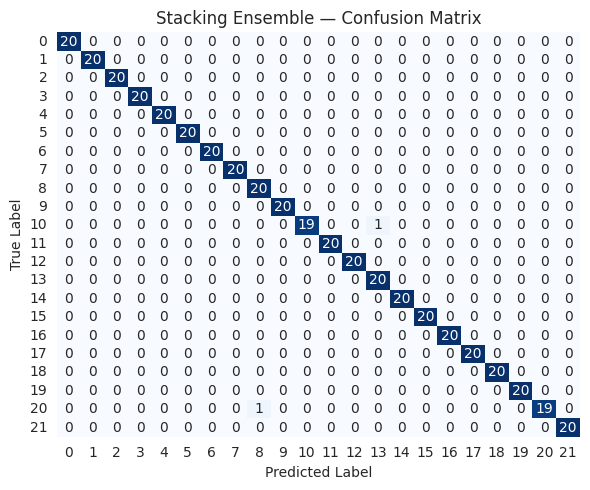

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,20.000000
1,1.000000,1.000000,1.000000,20.000000
2,1.000000,1.000000,1.000000,20.000000
3,1.000000,1.000000,1.000000,20.000000
4,1.000000,1.000000,1.000000,20.000000
5,1.000000,1.000000,1.000000,20.000000
6,1.000000,1.000000,1.000000,20.000000
7,1.000000,1.000000,1.000000,20.000000
8,0.952000,1.000000,0.976000,20.000000
9,1.000000,1.000000,1.000000,20.000000


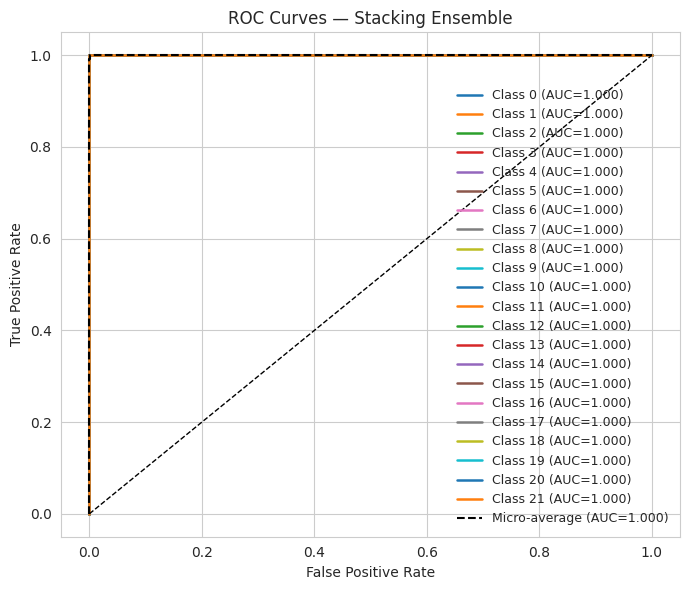

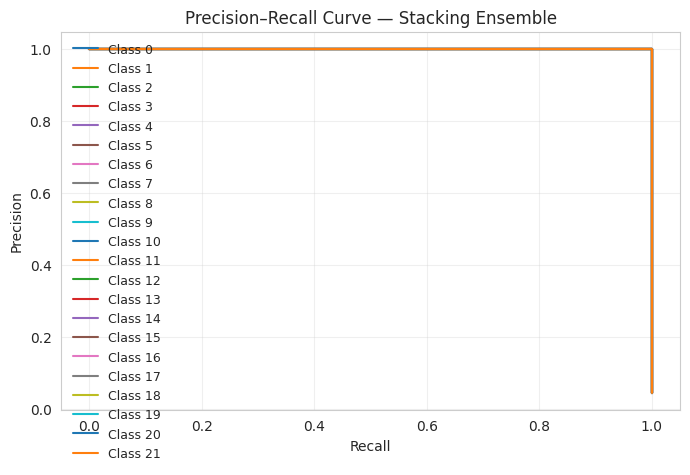

⚠️ Meta-learner importance skipped: Length of values (2420) does not match length of index (5)


In [49]:
# Case 3 / Step 2 — Stacking Ensemble (with visualizations)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score, precision_recall_curve
)
import numpy as np
import pandas as pd

#  Base Learners
logreg = make_logreg()
rf = make_rf()
svm = make_svm()
mlp = make_mlp()
xgb = make_xgb()

#  Define Stacking Ensemble
stacking_ensemble = StackingClassifier(
    estimators=[
        ("logreg", logreg),
        ("rf", rf),
        ("svm", svm),
        ("mlp", mlp),
        ("xgb", xgb),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1,
)

#  Train
stacking_ensemble.fit(X_train, y_train_encoded)

#  Evaluate
y_pred_stack = stacking_ensemble.predict(X_test)
y_proba_stack = stacking_ensemble.predict_proba(X_test)

acc_stack = accuracy_score(y_test_encoded, y_pred_stack)
f1_stack = f1_score(y_test_encoded, y_pred_stack, average="weighted")

print("\n=== 🏁 Stacking Ensemble Performance ===")
print(f"Accuracy : {acc_stack:.4f}")
print(f"F1 Score : {f1_stack:.4f}")




plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test_encoded, y_pred_stack)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Stacking Ensemble — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()




report = classification_report(y_test_encoded, y_pred_stack, output_dict=True)
report_df = pd.DataFrame(report).T.round(3)
display(report_df.style.background_gradient(cmap="YlGnBu", axis=0))




n_classes = y_proba_stack.shape[1]
y_test_bin = pd.get_dummies(y_test_encoded)

plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin.iloc[:, i], y_proba_stack[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.8, label=f"Class {i} (AUC={roc_auc:.3f})")

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.values.ravel(), y_proba_stack.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color="black", linestyle="--",
         label=f"Micro-average (AUC={roc_auc_micro:.3f})")

plt.plot([0,1],[0,1],"k--",lw=1)
plt.title("ROC Curves — Stacking Ensemble")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()




plt.figure(figsize=(7,5))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin.iloc[:, i], y_proba_stack[:, i])
    plt.plot(recall, precision, lw=1.5, label=f"Class {i}")

plt.title("Precision–Recall Curve — Stacking Ensemble")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()




try:
    meta_model = stacking_ensemble.final_estimator_
    coef = pd.Series(meta_model.coef_.flatten(),
                     index=[name for name, _ in stacking_ensemble.estimators])
    coef = coef.sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    sns.barplot(x=coef.values, y=coef.index,
                color="#ffcc66", edgecolor="black", linewidth=0.8)
    plt.title("Meta-learner (LogReg) Coefficients Importance")
    plt.xlabel("Coefficient Value (Impact on Prediction)")
    plt.ylabel("Base Model")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("⚠️ Meta-learner importance skipped:", e)


#Blending ensembler
Works similar to stacking ensemble where we create a meta model but the difference is that this existing one does not directly use the prediction but the probability of the prediction to determine how confident is each model with its prediction and thus forming a relative comparison about which model has better accuracy for which features and crop

✅ Trained base model: LogReg
✅ Trained base model: RF
✅ Trained base model: SVM
✅ Trained base model: MLP
✅ Trained base model: XGB
✅ Meta-learner trained (Logistic Regression).

=== 🏁 Blending Ensemble Results ===
Accuracy : 0.9932
F1 Score : 0.9932
AUC Score: 1.0000


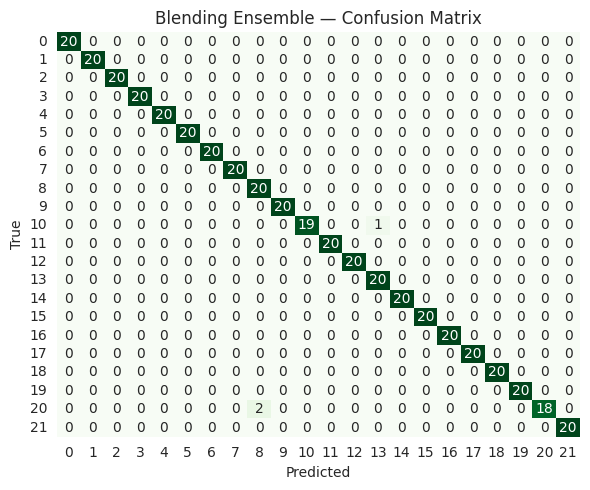

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,20.000000
1,1.000000,1.000000,1.000000,20.000000
2,1.000000,1.000000,1.000000,20.000000
3,1.000000,1.000000,1.000000,20.000000
4,1.000000,1.000000,1.000000,20.000000
5,1.000000,1.000000,1.000000,20.000000
6,1.000000,1.000000,1.000000,20.000000
7,1.000000,1.000000,1.000000,20.000000
8,0.909000,1.000000,0.952000,20.000000
9,1.000000,1.000000,1.000000,20.000000


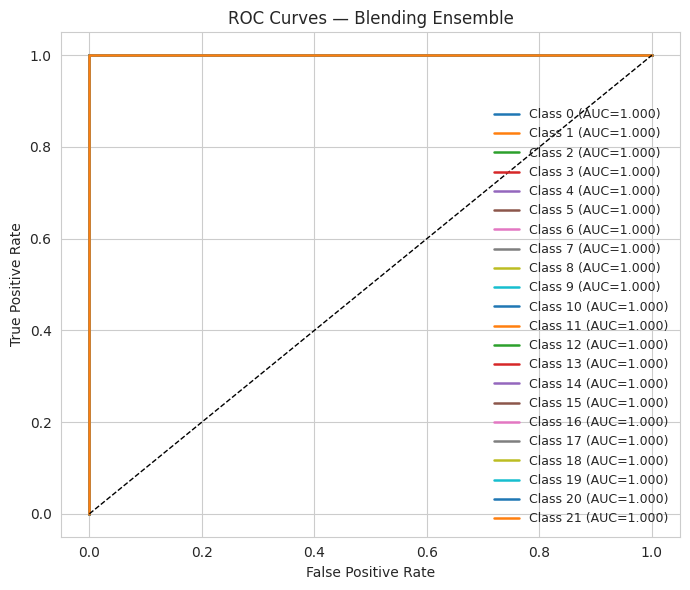

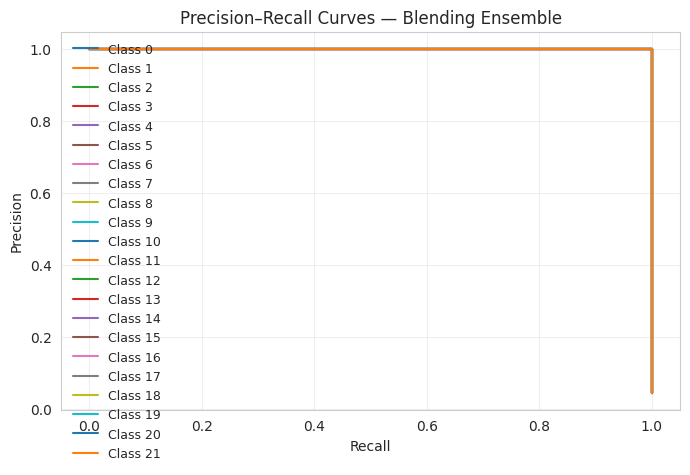

⚠️ Meta-importance skipped: Length of values (2420) does not match length of index (5)


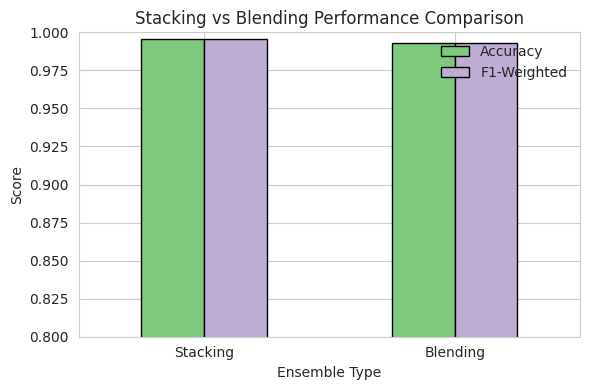

,Accuracy,F1-Weighted,AUC
Ensemble Type,,,
Stacking,0.9955,0.9955,1.0
Blending,0.9932,0.9932,1.0


,Model,Accuracy,F1_Weighted,AUC
0,BlendingEnsemble,0.993182,0.993169,1.000000


📊 Completed Case 3 / Step 3 — Blending Ensemble Evaluation


In [51]:

# Case 3 / Step 3 — Blending Ensemble (with visualizations)


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
import numpy as np
import pandas as pd

sns.set_style("whitegrid")



X_meta_train, X_meta_hold, y_meta_train, y_meta_hold = train_test_split(
    X_train, y_train_encoded,
    test_size=0.2, stratify=y_train_encoded, random_state=42
)


base_estimators = {
    "LogReg": make_logreg(),
    "RF": make_rf(),
    "SVM": make_svm(),
    "MLP": make_mlp(),
    "XGB": make_xgb(),
}


oof_preds = []
for name, model in base_estimators.items():
    model.fit(X_meta_train, y_meta_train)
    preds = model.predict_proba(X_meta_hold)
    oof_preds.append(preds)
    print(f"✅ Trained base model: {name}")


meta_X = np.hstack(oof_preds)
meta_lr = LogisticRegression(max_iter=2000, solver="lbfgs")
meta_lr.fit(meta_X, y_meta_hold)
print("✅ Meta-learner trained (Logistic Regression).")


test_preds = [model.predict_proba(X_test) for model in base_estimators.values()]
meta_X_test = np.hstack(test_preds)

y_pred_blend = meta_lr.predict(meta_X_test)
y_proba_blend = meta_lr.predict_proba(meta_X_test)

acc_blend = accuracy_score(y_test_encoded, y_pred_blend)
f1_blend = f1_score(y_test_encoded, y_pred_blend, average="weighted")
try:
    auc_blend = roc_auc_score(pd.get_dummies(y_test_encoded),
                              y_proba_blend,
                              average="weighted",
                              multi_class="ovr")
except Exception:
    auc_blend = np.nan

print("\n=== 🏁 Blending Ensemble Results ===")
print(f"Accuracy : {acc_blend:.4f}")
print(f"F1 Score : {f1_blend:.4f}")
print(f"AUC Score: {auc_blend:.4f}")


plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test_encoded, y_pred_blend)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Blending Ensemble — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


rep = classification_report(y_test_encoded, y_pred_blend, output_dict=True)
rep_df = pd.DataFrame(rep).T.round(3)
display(rep_df.style.background_gradient(cmap="YlGnBu", axis=0))


n_classes = len(np.unique(y_test_encoded))
y_test_bin = pd.get_dummies(y_test_encoded)

# --- ROC ---
plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin.iloc[:, i], y_proba_blend[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.8, label=f"Class {i} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--',lw=1)
plt.title("ROC Curves — Blending Ensemble")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# --- Precision–Recall ---
plt.figure(figsize=(7,5))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin.iloc[:, i], y_proba_blend[:, i])
    plt.plot(recall, precision, lw=1.5, label=f"Class {i}")
plt.title("Precision–Recall Curves — Blending Ensemble")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(frameon=False, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


try:
    coef = pd.Series(meta_lr.coef_.flatten(),
                     index=[f"{name}_prob" for name in base_estimators.keys()])
    coef = coef.sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    sns.barplot(x=coef.values, y=coef.index,
                color="#ffcc66", edgecolor="black", linewidth=0.8)
    plt.title("Meta-Learner Coefficients (Blending LR Model)")
    plt.xlabel("Coefficient Value (Effect on Final Prediction)")
    plt.ylabel("Base Model Feature Group")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("⚠️ Meta-importance skipped:", e)


try:
    comp_df = pd.DataFrame({
        "Ensemble Type": ["Stacking", "Blending"],
        "Accuracy": [acc_stack, acc_blend],
        "F1-Weighted": [f1_stack, f1_blend],
        "AUC": [np.nan if 'roc_auc_micro' not in locals() else roc_auc_micro, auc_blend]
    }).set_index("Ensemble Type")

    comp_df[["Accuracy", "F1-Weighted"]].plot(
        kind="bar", figsize=(6,4), color=["#7fc97f","#beaed4"],
        width=0.5, edgecolor="black"
    )
    plt.title("Stacking vs Blending Performance Comparison")
    plt.ylabel("Score")
    plt.ylim(0.8,1.0)
    plt.xticks(rotation=0)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    display(comp_df.round(4))
except Exception as e:
    print("⚠️ Comparison plot skipped:", e)

summary_case3_blend = pd.DataFrame({
    "Model": ["BlendingEnsemble"],
    "Accuracy": [acc_blend],
    "F1_Weighted": [f1_blend],
    "AUC": [auc_blend],
})
display(summary_case3_blend.style.highlight_max(axis=0, color="#b3e6b3"))

print("📊 Completed Case 3 / Step 3 — Blending Ensemble Evaluation")


#Final results of the super ensembler
Meta model of the existing meta model (optional to add in the paper not certainly needed)


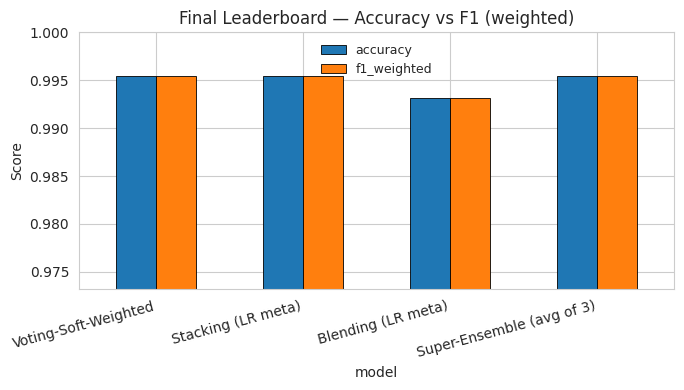

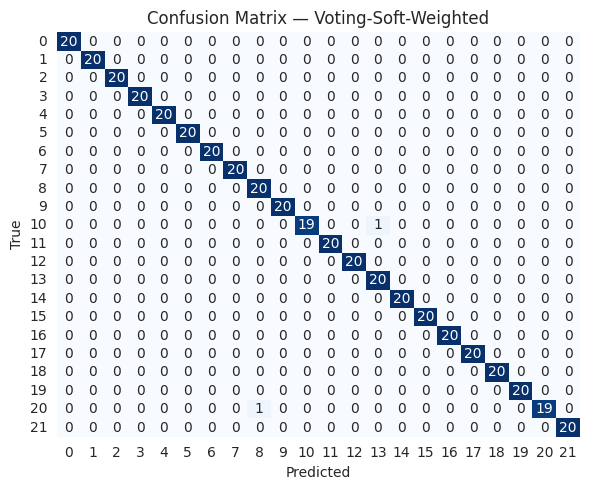

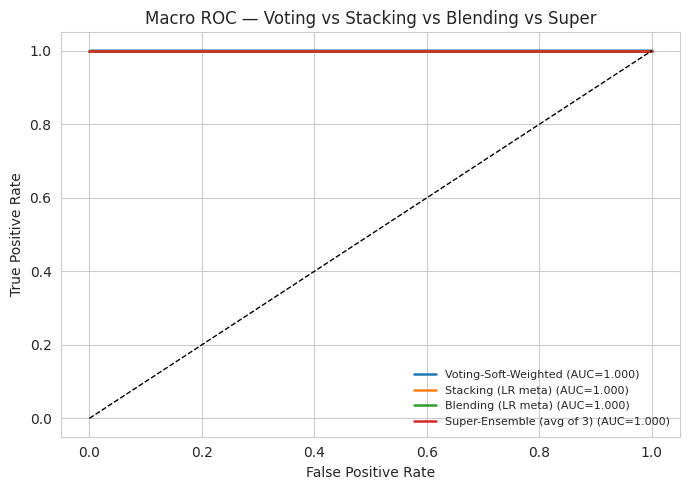

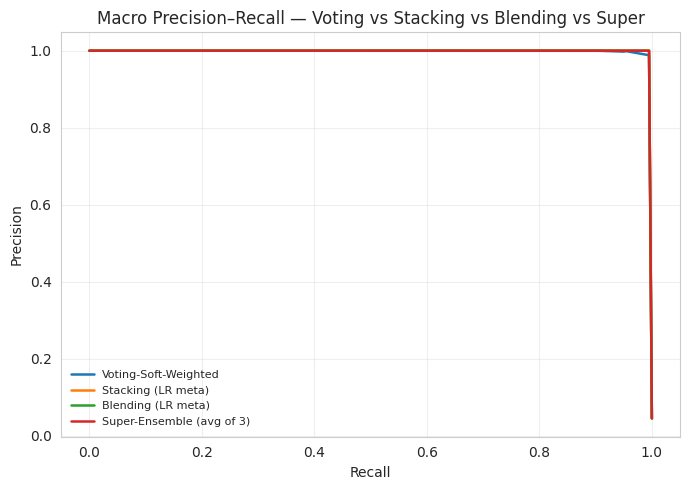

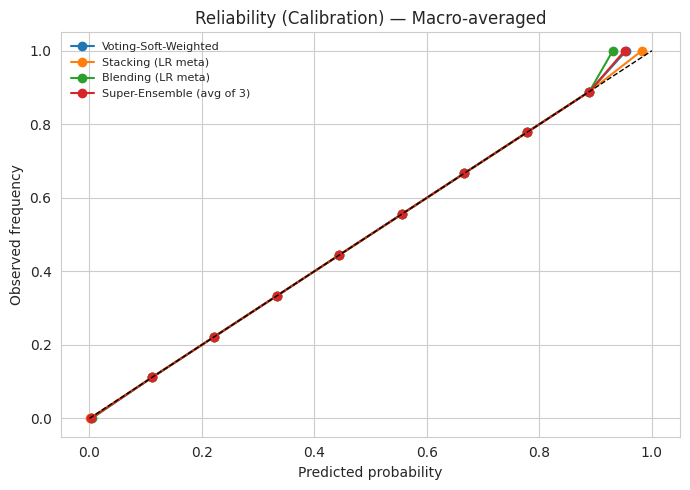

,model,brier_macro
1,Stacking (LR meta),0.000377
3,Super-Ensemble (avg of 3),0.000600
2,Blending (LR meta),0.000750
0,Voting-Soft-Weighted,0.001119


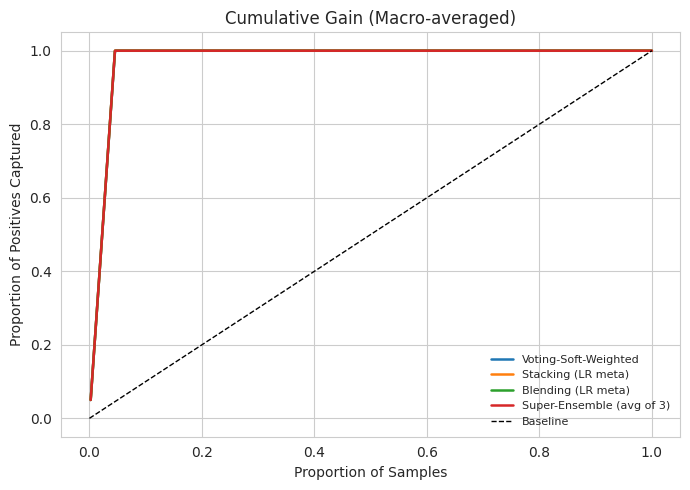

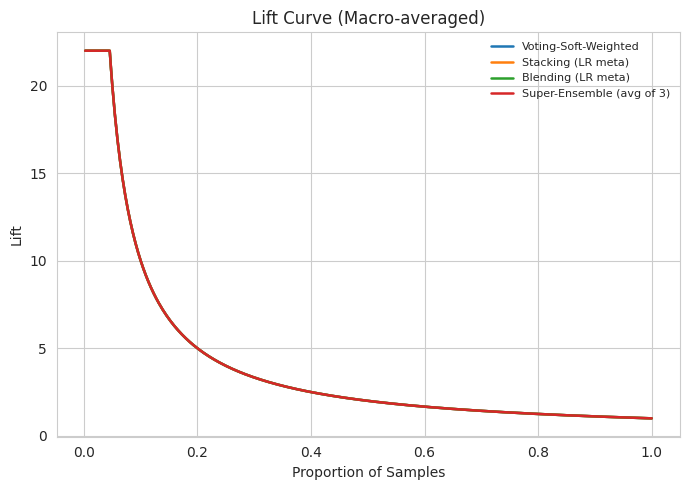

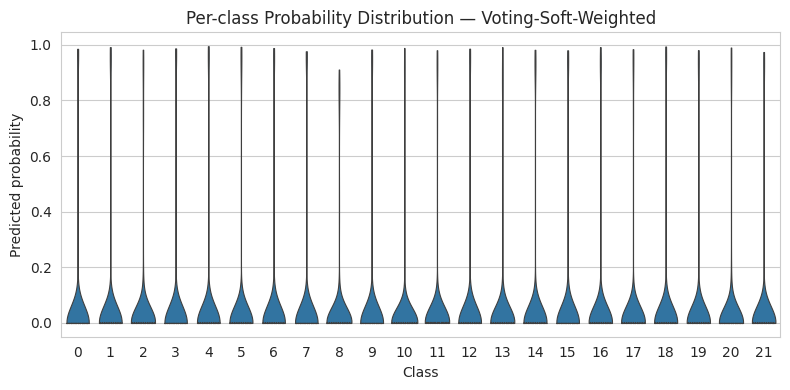


🏁 Final Ensemble Performance Summary:


,Model,Accuracy,F1-Weighted
0,Voting-Soft-Weighted,0.995500,0.995500
1,Stacking (LR meta),0.995500,0.995500
2,Super-Ensemble (avg of 3),0.995500,0.995500
3,Blending (LR meta),0.993200,0.993200



All figures saved in: /content/final_figs


In [56]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import VotingClassifier

sns.set_style("whitegrid")
FIGDIR = Path("final_figs"); FIGDIR.mkdir(exist_ok=True)


# 0) SAFETY/PREAMBLE — make sure proba arrays exist
#    (rebuild Voting-WeightedSoft from Step 1's best row)


def _ensure_list_feats(f):
    if isinstance(f, list): return f
    if isinstance(f, str):  return [x.strip() for x in f.split(",") if x.strip()]
    return list(f)

# 0a) Ensure Voting (Weighted Soft) test probabilities
if "y_proba_vote" not in globals():
    # We need results from Step 1
    assert "results_case3_vote" in globals(), "Run Case 3 / Step 1 before this cell."
    assert "BASE_BUILDERS" in globals() and "get_weights_for_strategy" in globals(), \
        "Builders/weight function missing — re-run Step 1 cell."

    # Pick best WeightedSoftVote across all rankings by test F1, then acc
    cand = results_case3_vote[results_case3_vote["ensemble"] == "WeightedSoftVote"]
    best_row = cand.sort_values(
        ["test_f1_weighted", "test_accuracy", "cv_f1_weighted", "cv_accuracy", "k_features"],
        ascending=[False, False, False, False, True]
    ).iloc[0]

    rank_name = best_row["ranking"]
    feats     = _ensure_list_feats(best_row["features_used"])

    # Rebuild the weighted-soft voting model
    base_models     = {name: maker() for name, maker in BASE_BUILDERS.items()}
    estimators_list = [(name, mdl) for name, mdl in base_models.items()]
    w               = get_weights_for_strategy(rank_name)
    weights_soft    = [w.get(name, 0.0) for name in base_models.keys()]

    wsv = VotingClassifier(estimators=estimators_list, voting="soft", weights=weights_soft)
    wsv.fit(X_train[feats], y_train_encoded)
    y_proba_vote = wsv.predict_proba(X_test[feats])
    y_pred_vote  = wsv.predict(X_test[feats])

# 0b) Ensure Stacking test probabilities
if "y_proba_stack" not in globals():
    assert "stacking_ensemble" in globals(), "Run Case 3 / Step 2 before this cell."
    y_proba_stack = stacking_ensemble.predict_proba(X_test)
    y_pred_stack  = stacking_ensemble.predict(X_test)

# 0c) Ensure Blending test probabilities
if "y_proba_blend" not in globals():
    # Expect meta_lr, meta_X_test from Step 3
    assert "meta_lr" in globals(), "Run Case 3 / Step 3 before this cell."
    assert "meta_X_test" in globals(), "Run Case 3 / Step 3 to build meta_X_test."
    y_proba_blend = meta_lr.predict_proba(meta_X_test)
    y_pred_blend  = meta_lr.predict(meta_X_test)

# 0d) Build df_results if missing (for the leaderboard bar)
if "df_results" not in globals():
    rows = []
    for name, proba in [
        ("Voting-Soft-Weighted", y_proba_vote),
        ("Stacking (LR meta)",  y_proba_stack),
        ("Blending (LR meta)",  y_proba_blend),
    ]:
        yhat = np.argmax(proba, axis=1)
        rows.append({
            "model": name,
            "accuracy": accuracy_score(y_test_encoded, yhat),
            "f1_weighted": f1_score(y_test_encoded, yhat, average="weighted"),
        })
    df_results = pd.DataFrame(rows).sort_values("f1_weighted", ascending=False).reset_index(drop=True)


# 1) Collect probabilities for all ensembles (consistent names)

proba_dict = {
    "Voting-Soft-Weighted": y_proba_vote,
    "Stacking (LR meta)":   y_proba_stack,
    "Blending (LR meta)":   y_proba_blend,
}
# Super-ensemble = simple average of the three
proba_super = np.mean(np.stack(list(proba_dict.values()), axis=0), axis=0)
proba_dict["Super-Ensemble (avg of 3)"] = proba_super


# 2) Leaderboard bar chart — Accuracy & F1 (safe version)

plt.figure(figsize=(7,4))

# Add Super-Ensemble row dynamically if not present
if "Super-Ensemble (avg of 3)" not in df_results["model"].values:
    yhat_super = np.argmax(proba_super, axis=1)
    acc_super = accuracy_score(y_test_encoded, yhat_super)
    f1_super  = f1_score(y_test_encoded, yhat_super, average="weighted")
    df_results = pd.concat([
        df_results,
        pd.DataFrame([{
            "model": "Super-Ensemble (avg of 3)",
            "accuracy": acc_super,
            "f1_weighted": f1_super
        }])
    ], ignore_index=True)

# Now safe to align indices
ranked = df_results.set_index("model").reindex(proba_dict.keys())
ranked[["accuracy","f1_weighted"]].plot(
    kind="bar", width=0.55, edgecolor="black", linewidth=0.6, ax=plt.gca()
)
plt.title("Final Leaderboard — Accuracy vs F1 (weighted)")
plt.ylabel("Score")
plt.ylim(max(0.0, ranked[["accuracy","f1_weighted"]].values.min()-0.02), 1.0)
plt.xticks(rotation=15, ha="right")
plt.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(FIGDIR / "leaderboard_acc_f1.png", dpi=200)
plt.show()



# 3) Confusion Matrix for the best model (by F1)

best_name = ranked["f1_weighted"].idxmax()
best_proba = proba_dict[best_name]
best_pred  = np.argmax(best_proba, axis=1)

plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test_encoded, best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(FIGDIR / f"cm_{best_name.replace(' ', '_')}.png", dpi=200)
plt.show()


# 4) Macro ROC curves

def macro_roc(y_true, proba):
    k = proba.shape[1]
    y_bin = pd.get_dummies(y_true)
    aucs, curves = [], []
    for i in range(k):
        fpr, tpr, _ = roc_curve(y_bin.iloc[:, i], proba[:, i])
        aucs.append(auc(fpr, tpr)); curves.append((fpr, tpr))
    mean_auc = np.mean(aucs)
    all_fpr = np.unique(np.concatenate([c[0] for c in curves]))
    mean_tpr = np.zeros_like(all_fpr)
    for fpr, tpr in curves:
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= k
    return all_fpr, mean_tpr, mean_auc

plt.figure(figsize=(7,5))
for name, proba in proba_dict.items():
    fpr, tpr, mauc = macro_roc(y_test_encoded, proba)
    plt.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={mauc:.3f})")
plt.plot([0,1],[0,1],'k--',lw=1)
plt.title("Macro ROC — Voting vs Stacking vs Blending vs Super")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "macro_roc_all.png", dpi=200)
plt.show()


# 5) Macro Precision–Recall curves

def macro_pr(y_true, proba):
    k = proba.shape[1]
    y_bin = pd.get_dummies(y_true)
    recall_grid = np.linspace(0, 1, 200)
    precisions = []
    for i in range(k):
        precision, recall, _ = precision_recall_curve(y_bin.iloc[:, i], proba[:, i])
        order = np.argsort(recall)
        recall, precision = recall[order], precision[order]
        precisions.append(np.interp(recall_grid, recall, precision, left=1.0, right=0.0))
    return recall_grid, np.mean(precisions, axis=0)

plt.figure(figsize=(7,5))
for name, proba in proba_dict.items():
    r, p = macro_pr(y_test_encoded, proba)
    plt.plot(r, p, lw=1.8, label=name)
plt.title("Macro Precision–Recall — Voting vs Stacking vs Blending vs Super")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGDIR / "macro_pr_all.png", dpi=200)
plt.show()


# 6) Calibration (Reliability) + Brier score (macro-avg)

plt.figure(figsize=(7,5))
for name, proba in proba_dict.items():
    y_bin = pd.get_dummies(y_test_encoded)
    fracs, means = [], []
    for i in range(proba.shape[1]):
        frac_pos, mean_pred = calibration_curve(
            y_bin.iloc[:, i], proba[:, i], n_bins=10, strategy="uniform"
        )
        fracs.append(frac_pos)
        means.append(mean_pred)

    #  interpolate to common 0–1 grid to handle length mismatch
    grid = np.linspace(0, 1, 10)
    fracs_interp = [np.interp(grid, f, f) if len(f) > 1 else np.zeros_like(grid) for f in fracs]
    means_interp = [np.interp(grid, m, m) if len(m) > 1 else np.zeros_like(grid) for m in means]

    frac_pos = np.mean(fracs_interp, axis=0)
    mean_pred = np.mean(means_interp, axis=0)

    plt.plot(mean_pred, frac_pos, marker='o', lw=1.5, label=name)

plt.plot([0,1],[0,1],'k--',lw=1)
plt.title("Reliability (Calibration) — Macro-averaged")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "calibration_macro.png", dpi=200)
plt.show()

brier_rows = []
y_bin_all = pd.get_dummies(y_test_encoded).values
for name, proba in proba_dict.items():
    briers = [brier_score_loss(y_bin_all[:, i], proba[:, i]) for i in range(proba.shape[1])]
    brier_rows.append({"model": name, "brier_macro": float(np.mean(briers))})
brier_df = pd.DataFrame(brier_rows).sort_values("brier_macro")
display(brier_df.style.background_gradient(cmap="YlGnBu", axis=0))


# 7) Cumulative Gain + Lift (macro proxies)

def cumulative_gain(y_true, proba):
    y_bin = pd.get_dummies(y_true).values
    gains = []
    for i in range(proba.shape[1]):
        order = np.argsort(-proba[:, i])
        y_sorted = y_bin[order, i]
        cum_pos = np.cumsum(y_sorted)
        total_pos = y_sorted.sum()
        perc_samples = np.arange(1, len(y_true)+1) / len(y_true)
        gain = cum_pos / (total_pos if total_pos > 0 else 1)
        gains.append((perc_samples, gain))
    xs = gains[0][0]; ys = np.mean([g[1] for g in gains], axis=0)
    return xs, ys

plt.figure(figsize=(7,5))
for name, proba in proba_dict.items():
    xs, ys = cumulative_gain(y_test_encoded, proba)
    plt.plot(xs, ys, lw=1.8, label=name)
plt.plot([0,1],[0,1],'k--',lw=1,label="Baseline")
plt.title("Cumulative Gain (Macro-averaged)")
plt.xlabel("Proportion of Samples"); plt.ylabel("Proportion of Positives Captured")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "cumulative_gain_macro.png", dpi=200)
plt.show()

plt.figure(figsize=(7,5))
for name, proba in proba_dict.items():
    xs, ys = cumulative_gain(y_test_encoded, proba)
    lift = ys / np.clip(xs, 1e-6, None)
    plt.plot(xs, lift, lw=1.8, label=name)
plt.title("Lift Curve (Macro-averaged)")
plt.xlabel("Proportion of Samples"); plt.ylabel("Lift")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "lift_macro.png", dpi=200)
plt.show()


# 8) Per-class probability violin — best model

best_proba_df = pd.DataFrame(best_proba)
best_proba_df["true"] = y_test_encoded
best_proba_melt = best_proba_df.melt(id_vars="true", var_name="class", value_name="p_hat")

plt.figure(figsize=(8,4))
sns.violinplot(data=best_proba_melt, x="class", y="p_hat", cut=0, inner="quartile", linewidth=0.8)
plt.title(f"Per-class Probability Distribution — {best_name}")
plt.xlabel("Class"); plt.ylabel("Predicted probability")
plt.tight_layout()
plt.savefig(FIGDIR / f"violin_probs_{best_name.replace(' ', '_')}.png", dpi=200)
plt.show()


# 9) Numerical summary — Accuracy & F1 for all ensembles

summary_rows = []
for name, proba in proba_dict.items():
    yhat = np.argmax(proba, axis=1)
    acc = accuracy_score(y_test_encoded, yhat)
    f1w = f1_score(y_test_encoded, yhat, average="weighted")
    summary_rows.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "F1-Weighted": round(f1w, 4)
    })

summary_df = pd.DataFrame(summary_rows).sort_values("F1-Weighted", ascending=False).reset_index(drop=True)
print("\n🏁 Final Ensemble Performance Summary:")
display(summary_df.style.background_gradient(cmap="Greens", axis=0))

print(f"\nAll figures saved in: {FIGDIR.resolve()}")
